# Secure Gateway — Multi-Modal Biometric Authentication System
### Deep Learning Final Project

A security system that combines **three verification factors** to grant access through a secure gateway:

| Factor | Method | Model | Output |
|---|---|---|---|
| **Face Recognition** | Facial feature verification | FaceNet (InceptionResnetV1) | 512-dim embedding |
| **Speaker Verification** | Voice identity confirmation | ECAPA-TDNN (SpeechBrain) | 192-dim embedding |
| **Spoken Password** | Speech-to-text passphrase check | Google Speech Recognition | Fuzzy text match |

All three factors must pass for authentication to succeed.

**Architecture Overview:**
```
User speaks password
  → Gate 1: Voice Password (STT + fuzzy match ≥ 0.75)
  → Gate 2: Biometric Capture
       ├── Face  → MTCNN → FaceNet → 512-dim embedding
       └── Voice → ECAPA-TDNN → 192-dim embedding
  → Gate 3: Late Fusion MLP (704-dim input → 4-class identity)
  → 3-Tier Decision → ACCESS GRANTED / DENIED
```

**Approach:** We use **transfer learning** — pretrained models (FaceNet on VGGFace2, ECAPA-TDNN on VoxCeleb) serve as frozen feature extractors. Only the final fusion MLP is trained on our data. A **Late Fusion** strategy combines face and voice embeddings at the decision layer, allowing each modality to contribute independently.

**Registered Users:** David, Itzhak, Yossi (~30 face photos and ~30 voice clips each).

---
## 0. Install Dependencies

Key packages:
- **facenet-pytorch** — MTCNN face detection + InceptionResnetV1 (FaceNet) embeddings
- **speechbrain** — ECAPA-TDNN speaker verification model
- **SpeechRecognition** — Google Speech-to-Text API wrapper
- **torchaudio** — audio loading, resampling, and augmentation
- **opencv-python** — image processing and visualization

In [ ]:
# Run this cell once to install all required packages
!pip install facenet-pytorch Pillow opencv-python torchaudio soundfile tqdm numpy

In [ ]:
!pip install speechbrain

In [ ]:
!pip install "huggingface_hub<0.20.0" speechbrain --upgrade

In [ ]:
# install SpeechRecognition
!pip install SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 42.9 MB/s eta 0:00:00


---
## 1. Imports

Core libraries for both pipelines:
- **PyTorch + torchvision + torchaudio** — tensor operations, image transforms, audio processing
- **facenet_pytorch** — MTCNN (face detection) and InceptionResnetV1 (face embeddings)
- **PIL / OpenCV** — image loading, filtering, enhancement
- **NumPy** — numerical operations for augmentation

In [ ]:
import os
import sys
import random
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance

import torch
import torchaudio
from torchvision import transforms
import cv2

from facenet_pytorch import MTCNN
from tqdm import tqdm

print(f"PyTorch version:      {torch.__version__}")
print(f"torchaudio version:   {torchaudio.__version__}")
print(f"CUDA available:       {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:         {DEVICE}")

PyTorch version:      2.2.2+cu121
torchaudio version:   2.2.2+cu121
CUDA available:       True
Using device:         cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Verify Google Drive is mounted and accessible
!ls /content/drive/MyDrive/data

face  ignore  voice


---
## 2. Configuration

All tunable parameters for both pipelines are defined here. Key settings:
- **Face:** 160x160 crop size, MTCNN confidence 0.95, 15 augmentations per image
- **Voice:** 16kHz sample rate, silence threshold -40dB, 3 augmentations per clip



In [ ]:
# ── FACE PIPELINE ─────────────────────────────────────────────

FACE_RAW_DIR       = "/content/drive/MyDrive/data/face/raw"        # Input: raw photos organized by person
FACE_PROCESSED_DIR = "/content/drive/MyDrive/data/face/processed"  # Output: clean 160×160 face images
FACE_AUGMENTED_DIR = "/content/drive/MyDrive/data/face/augmented"

IMAGE_SIZE           = 160    # Output face size in pixels (160×160 for FaceNet)
MARGIN               = 40     # Extra pixels around the detected face (40 = good default)
                               # Increase to 60 if faces look too tightly cropped
MIN_FACE_SIZE        = 50     # Minimum face size to detect; lower for low-res photos
CONFIDENCE_THRESHOLD = 0.95   # Min MTCNN confidence to accept a detection
                               # Lower to 0.90 if too many valid photos are being dropped
# Augmentation settings
AUGMENTATIONS_PER_IMAGE = 15  # Number of augmented versions to create from each original photo
COPY_ORIGINALS = True # Whether to include the original cropped face in the augmented dataset (recommended)
RANDOM_SEED = 42 # Set a fixed random seed for reproducibility of augmentations

In [ ]:
# ── VOICE PIPELINE ────────────────────────────────────────────

VOICE_RAW_DIR       = "/content/drive/MyDrive/data/voice/raw"       # Input: recordings organized by person/type
VOICE_PROCESSED_DIR = "/content/drive/MyDrive/data/voice/processed" # Output: clean WAV files
VOICE_AUGMENTED_DIR = "/content/drive/MyDrive/data/voice/augmented"

TARGET_SAMPLE_RATE = 16000  # 16kHz — standard for speech/speaker verification models
TARGET_CHANNELS    = 1      # Mono — speech models expect single-channel audio

# Silence trimming
TRIM_SILENCE          = True   # Whether to trim leading/trailing silence
SILENCE_THRESHOLD_DB  = -40   # Below this dB = silence. Use -30 for noisy rooms,
                               # -50 for very clean mics
MIN_SILENCE_DURATION  = 0.1   # Min silence duration (s) to trigger trimming
SILENCE_PADDING       = 0.15  # Seconds of silence to keep at start/end after trimming

# Volume normalization
NORMALIZE_VOLUME  = True   # Normalize amplitude across all recordings
PEAK_NORMALIZE_DB = -1.0   # Target peak dB (-1.0 leaves headroom to avoid clipping)

# Quality checks
MIN_DURATION_SEC = 0.5    # Minimum valid recording length in seconds
MAX_DURATION_SEC = 30.0   # Maximum valid recording length in seconds
MIN_RMS_DB       = -50    # Minimum RMS energy — filters out silent/empty files

RECORDING_CATEGORIES = ["password", "short", "long"]  # Expected subfolders per person

# Augmentation settings
AUGMENTATIONS_PER_CLIP = 3 # Number of augmented versions to create from each original recording

In [ ]:
# Output paths
EMBEDDINGS_DIR = "/content/drive/MyDrive/data/embeddings"
FACE_EMBEDDINGS_FILE = "face_embeddings.pt"
VOICE_EMBEDDINGS_FILE = "voice_embeddings.pt"

# Processing settings
BATCH_SIZE = 32  # Batch size for embedding computation (adjust based on GPU memory)

# Voice settings
VOICE_SAMPLE_RATE = 16000

---
## 3. Face Preprocessing Pipeline

FaceNet expects aligned, tightly-cropped 160x160 face images — but raw photos contain backgrounds, varying poses, and sometimes multiple faces. This step isolates the face region so the embedding model receives clean, consistent input.

**What it does:**
1. Loads each raw photo
2. Runs MTCNN to detect, align (via eye landmarks), and crop the face
3. Resizes to 160×160 pixels
4. Saves as PNG to `data/face/processed/<person_name>/`

MTCNN operates in 3 stages — P-Net (candidate regions) → R-Net (refinement) → O-Net (landmarks + final crop).

In [ ]:
def create_face_detector(device="cpu"):
    """
    Create an MTCNN face detector.

    MTCNN (Multi-Task Cascaded Convolutional Network) works in 3 stages:
      Stage 1 (P-Net): Scans image at multiple scales to find candidate regions
      Stage 2 (R-Net): Refines candidates, removes false positives
      Stage 3 (O-Net): Final refinement + outputs 5 facial landmarks

    The landmarks (eyes, nose, mouth corners) are used for alignment —
    rotating the face so the eyes are always horizontal.
    """
    detector = MTCNN(
        image_size=IMAGE_SIZE,
        margin=MARGIN,
        min_face_size=MIN_FACE_SIZE,
        thresholds=[0.6, 0.7, 0.7],  # Confidence thresholds for the 3 MTCNN stages
        factor=0.709,                 # Scale factor for image pyramid
        post_process=False,           # Don't normalize yet — we'll do it ourselves
        keep_all=False,               # Only keep the largest/most confident face
        device=device,
        select_largest=True,
    )
    return detector

In [ ]:
def detect_and_crop_face(detector, image_path):
    """
    Detect, align, and crop a face from a single image.

    Returns:
        face_image (PIL.Image): Cropped, aligned face at 160×160 RGB
        confidence (float):     Detection confidence score
        OR (None, None) / (None, confidence) if detection fails
    """

    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"  [ERROR] Could not load image: {image_path} — {e}")
        return None, None

    # First pass: get confidence score
    boxes, confidence = detector.detect(img)

    if confidence is None or len(confidence) == 0 or confidence[0] is None:
        return None, None

    best_confidence = confidence[0]

    if best_confidence < CONFIDENCE_THRESHOLD:
        return None, best_confidence

    # Second pass: detect + align + crop in one call
    face_cropped = detector(img)  # Returns tensor (3, 160, 160) or None

    if face_cropped is None:
        return None, None

    # Tensor (3,160,160) → numpy (160,160,3) → PIL Image
    face_np = face_cropped.permute(1, 2, 0).numpy()
    face_np = np.clip(face_np, 0, 255).astype(np.uint8)
    face_image = Image.fromarray(face_np)

    return face_image, best_confidence

In [ ]:
def process_face_person(detector, person_name, raw_dir, output_dir):
    """
    Process all face images for one person.
      Reads from:  raw_dir/<person_name>/
      Saves to:    output_dir/<person_name>/

    Returns a stats dict with counts of success/failure.
    """
    input_folder  = os.path.join(raw_dir, person_name)
    output_folder = os.path.join(output_dir, person_name)
    os.makedirs(output_folder, exist_ok=True)

    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}
    image_files = [
        f for f in sorted(os.listdir(input_folder))
        if os.path.splitext(f)[1].lower() in valid_extensions
    ]

    if not image_files:
        print(f"  [WARNING] No images found in {input_folder}")
        return {"total": 0, "success": 0, "failed": 0, "low_confidence": 0}

    stats = {"total": len(image_files), "success": 0, "failed": 0, "low_confidence": 0}
    failed_files = []

    print(f"\n  Processing {len(image_files)} images for '{person_name}'...")

    for filename in tqdm(image_files, desc=f"  {person_name}", leave=True):
        image_path = os.path.join(input_folder, filename)
        face_image, confidence = detect_and_crop_face(detector, image_path)

        if face_image is None:
            if confidence is not None and confidence < CONFIDENCE_THRESHOLD:
                stats["low_confidence"] += 1
                failed_files.append((filename, f"low confidence: {confidence:.3f}"))
            else:
                stats["failed"] += 1
                failed_files.append((filename, "no face detected"))
            continue

        output_filename = os.path.splitext(filename)[0] + ".png"
        output_path = os.path.join(output_folder, output_filename)
        face_image.save(output_path, "PNG")
        stats["success"] += 1

    print(f"  Results for '{person_name}':")
    print(f"    ✓ Success:        {stats['success']}/{stats['total']}")
    print(f"    ✗ No face found:  {stats['failed']}")
    print(f"    ⚠ Low confidence: {stats['low_confidence']}")

    if failed_files:
        print(f"  Failed files:")
        for fname, reason in failed_files:
            print(f"    - {fname}: {reason}")

    return stats

In [ ]:
!ls /content/drive/MyDrive/data/face/raw

david  itzhak  unknown	yossi


In [ ]:
def run_face_preprocessing():
    """Run the full face preprocessing pipeline."""
    print("=" * 60)
    print("  FACE DATA PREPROCESSING PIPELINE")
    print("=" * 60)

    if not os.path.exists(FACE_RAW_DIR):
        print(f"\n[ERROR] Raw data directory not found: {FACE_RAW_DIR}")
        print(f"Expected structure:")
        print(f"  {FACE_RAW_DIR}/")
        print(f"    ├── person1/  (photo1.jpg, photo2.jpg, ...)")
        print(f"    └── person2/")
        return

    person_folders = [
        d for d in sorted(os.listdir(FACE_RAW_DIR))
        if os.path.isdir(os.path.join(FACE_RAW_DIR, d)) and not d.startswith(".")
    ]

    if not person_folders:
        print(f"\n[ERROR] No person folders found in {FACE_RAW_DIR}")
        return

    print(f"\nFound {len(person_folders)} people: {', '.join(person_folders)}")
    print(f"Input:    {FACE_RAW_DIR}")
    print(f"Output:   {FACE_PROCESSED_DIR}")
    print(f"Settings: image_size={IMAGE_SIZE}, margin={MARGIN}, min_face={MIN_FACE_SIZE}")

    os.makedirs(FACE_PROCESSED_DIR, exist_ok=True)

    print("\nLoading MTCNN face detector...")
    detector = create_face_detector(device=DEVICE)
    print("Detector ready.\n")

    all_stats = {}
    for person_name in person_folders:
        stats = process_face_person(detector, person_name, FACE_RAW_DIR, FACE_PROCESSED_DIR)
        all_stats[person_name] = stats

    # ── Summary ────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  FACE PREPROCESSING COMPLETE — SUMMARY")
    print("=" * 60)

    total_images   = sum(s["total"]          for s in all_stats.values())
    total_success  = sum(s["success"]         for s in all_stats.values())
    total_failed   = sum(s["failed"]          for s in all_stats.values())
    total_low_conf = sum(s["low_confidence"]  for s in all_stats.values())

    print(f"\n  {'Person':<15} {'Total':<8} {'Success':<10} {'Failed':<10} {'Low Conf':<10}")
    print(f"  {'-'*53}")
    for person, s in all_stats.items():
        print(f"  {person:<15} {s['total']:<8} {s['success']:<10} {s['failed']:<10} {s['low_confidence']:<10}")
    print(f"  {'-'*53}")
    print(f"  {'TOTAL':<15} {total_images:<8} {total_success:<10} {total_failed:<10} {total_low_conf:<10}")

    if total_images > 0:
        print(f"\n  Overall success rate: {total_success / total_images * 100:.1f}%")

    if total_failed > 0 or total_low_conf > 0:
        print(f"\n  Tips for failed images:")
        print(f"  - Ensure face is visible, well-lit, and not occluded")
        print(f"  - Try lowering CONFIDENCE_THRESHOLD to 0.90")
        print(f"  - For small faces, try lowering MIN_FACE_SIZE to 30")

    print(f"\n  Processed images saved to: {FACE_PROCESSED_DIR}/\n")


# ▶ Run the face pipeline
run_face_preprocessing()

  FACE DATA PREPROCESSING PIPELINE

Found 4 people: david, itzhak, unknown, yossi
Input:    /content/drive/MyDrive/data/face/raw
Output:   /content/drive/MyDrive/data/face/processed
Settings: image_size=160, margin=40, min_face=50

Loading MTCNN face detector...
Detector ready.


  Processing 82 images for 'david'...


  david: 100%|██████████| 82/82 [01:16<00:00,  1.07it/s]


  Results for 'david':
    ✓ Success:        51/82
    ✗ No face found:  21
    ⚠ Low confidence: 10
  Failed files:
    - 1.jpg: no face detected
    - 10.jpg: no face detected
    - 11.jpg: no face detected
    - 12.jpg: low confidence: 0.777
    - 13.jpg: no face detected
    - 14.jpg: low confidence: 0.935
    - 15.jpg: no face detected
    - 16.jpg: low confidence: 0.898
    - 17.jpg: low confidence: 0.713
    - 18.jpg: no face detected
    - 19.jpg: no face detected
    - 2.jpg: no face detected
    - 20.jpg: low confidence: 0.944
    - 21.jpg: no face detected
    - 23.jpg: no face detected
    - 3.jpg: no face detected
    - 32.jpg: no face detected
    - 33.jpg: no face detected
    - 38.jpg: low confidence: 0.805
    - 39.jpg: no face detected
    - 4.jpg: low confidence: 0.768
    - 40.jpg: low confidence: 0.852
    - 41.jpg: low confidence: 0.707
    - 42.jpg: no face detected
    - 43.jpg: no face detected
    - 44.jpg: no face detected
    - 5.jpg: low confidence: 0.910
 

  itzhak: 100%|██████████| 30/30 [00:35<00:00,  1.18s/it]


  Results for 'itzhak':
    ✓ Success:        29/30
    ✗ No face found:  0
    ⚠ Low confidence: 1
  Failed files:
    - IMG_1798.jpg: low confidence: 0.776
  [WARNING] No images found in /content/drive/MyDrive/data/face/raw/unknown

  Processing 30 images for 'yossi'...


  yossi: 100%|██████████| 30/30 [00:27<00:00,  1.10it/s]

  Results for 'yossi':
    ✓ Success:        28/30
    ✗ No face found:  2
    ⚠ Low confidence: 0
  Failed files:
    - 21.jpg: no face detected
    - 8.jpg: no face detected

  FACE PREPROCESSING COMPLETE — SUMMARY

  Person          Total    Success    Failed     Low Conf  
  -----------------------------------------------------
  david           82       51         21         10        
  itzhak          30       29         0          1         
  unknown         0        0          0          0         
  yossi           30       28         2          0         
  -----------------------------------------------------
  TOTAL           142      108        23         11        

  Overall success rate: 76.1%

  Tips for failed images:
  - Ensure face is visible, well-lit, and not occluded
  - Try lowering CONFIDENCE_THRESHOLD to 0.90
  - For small faces, try lowering MIN_FACE_SIZE to 30

  Processed images saved to: /content/drive/MyDrive/data/face/processed/



---
## 4. Voice Preprocessing Pipeline

ECAPA-TDNN expects clean 16kHz mono audio — but raw recordings vary in format, sample rate, volume, and may contain long silences. This step standardizes all clips so the speaker model receives uniform input.

**What it does (per recording):**
1. **Load** — supports WAV, MP3, FLAC, OGG, M4A and more
2. **Validate** — checks duration, RMS energy, and data integrity
3. **Mono conversion** — averages stereo channels
4. **Resample** — converts to 16kHz (required by speaker verification models)
5. **Trim silence** — removes leading/trailing silence, keeps a short pad
6. **Normalize volume** — peak-normalizes to −1.0 dBFS
7. **Re-validate** — post-processing quality check
8. **Save** — 16-bit PCM WAV to `data/voice/processed/<person>/<category>/`

In [ ]:
def load_audio(file_path):
    """
    Load an audio file and return (waveform, sample_rate).
    waveform shape: (channels, num_samples)
    Returns (None, None) on failure.
    """
    try:
        waveform, sample_rate = torchaudio.load(file_path)
        return waveform, sample_rate
    except Exception as e:
        print(f"  [ERROR] Could not load audio: {file_path} — {e}")
        return None, None


def validate_audio(waveform, sample_rate, filename):
    """
    Quality checks: duration range, RMS energy, and no NaN/Inf values.
    Returns (is_valid: bool, reason: str).
    """
    duration = waveform.shape[1] / sample_rate

    if duration < MIN_DURATION_SEC:
        return False, f"too short ({duration:.2f}s < {MIN_DURATION_SEC}s)"
    if duration > MAX_DURATION_SEC:
        return False, f"too long ({duration:.2f}s > {MAX_DURATION_SEC}s)"
    if torch.isnan(waveform).any() or torch.isinf(waveform).any():
        return False, "contains NaN or Inf values (corrupted)"

    rms = torch.sqrt(torch.mean(waveform ** 2))
    if rms == 0:
        return False, "completely silent (zero RMS)"

    rms_db = 20 * torch.log10(rms + 1e-10)
    if rms_db < MIN_RMS_DB:
        return False, f"too quiet (RMS={rms_db:.1f} dB < {MIN_RMS_DB} dB)"

    return True, "ok"

In [ ]:
def convert_to_mono(waveform):
    """
    Average multi-channel audio to mono.
    Input:  (channels, samples)  →  Output: (1, samples)
    """
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return waveform


def resample_audio(waveform, orig_sr, target_sr):
    """
    Resample audio to target_sr using polyphase filtering.
    Speech models expect 16kHz; this normalizes across different recording devices.
    """
    if orig_sr == target_sr:
        return waveform
    resampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=target_sr)
    return resampler(waveform)


def trim_silence_from_audio(waveform, sample_rate):
    """
    Remove leading and trailing silence from the waveform.

    Algorithm:
      1. Convert SILENCE_THRESHOLD_DB to linear amplitude
      2. Find first and last samples above the threshold
      3. Trim, then restore SILENCE_PADDING seconds at each end

    This reduces recording length variability and removes wasted computation
    during embedding extraction.
    """
    if not TRIM_SILENCE:
        return waveform

    threshold_linear = 10 ** (SILENCE_THRESHOLD_DB / 20)
    audio_abs = torch.abs(waveform[0])
    above_threshold = audio_abs > threshold_linear

    if not above_threshold.any():
        return waveform  # Fully silent — return as-is, will fail validation

    nonzero_indices = torch.where(above_threshold)[0]
    start_idx = nonzero_indices[0].item()
    end_idx   = nonzero_indices[-1].item()

    pad_samples = int(SILENCE_PADDING * sample_rate)
    start_idx = max(0, start_idx - pad_samples)
    end_idx   = min(waveform.shape[1], end_idx + pad_samples)

    return waveform[:, start_idx:end_idx]


def normalize_volume(waveform):
    """
    Peak-normalize audio to PEAK_NORMALIZE_DB.
    Ensures consistent amplitude across recordings from different mics/environments.
    """
    if not NORMALIZE_VOLUME:
        return waveform

    peak = torch.max(torch.abs(waveform))
    if peak == 0:
        return waveform  # Avoid division by zero

    target_peak = 10 ** (PEAK_NORMALIZE_DB / 20)
    gain = target_peak / peak
    return waveform * gain

In [ ]:
def process_single_audio(file_path):
    """
    Full preprocessing pipeline for a single audio file:
      Load → Validate → Mono → Resample → Trim → Normalize → Re-validate

    Returns:
        (processed_waveform, metadata_dict)   on success
        (None, error_dict)                    on failure
    """
    waveform, sample_rate = load_audio(file_path)
    if waveform is None:
        return None, {"error": "failed to load"}

    filename         = os.path.basename(file_path)
    original_duration = waveform.shape[1] / sample_rate
    original_sr       = sample_rate

    is_valid, reason = validate_audio(waveform, sample_rate, filename)
    if not is_valid:
        return None, {"error": reason}

    waveform = convert_to_mono(waveform)
    waveform = resample_audio(waveform, sample_rate, TARGET_SAMPLE_RATE)
    sample_rate = TARGET_SAMPLE_RATE
    waveform = trim_silence_from_audio(waveform, sample_rate)
    waveform = normalize_volume(waveform)

    final_duration = waveform.shape[1] / sample_rate
    if final_duration < MIN_DURATION_SEC:
        return None, {"error": f"too short after trimming ({final_duration:.2f}s)"}

    metadata = {
        "original_sample_rate": original_sr,
        "original_duration":    round(original_duration, 2),
        "processed_duration":   round(final_duration, 2),
        "final_sample_rate":    sample_rate,
        "trimmed_seconds":      round(original_duration - final_duration, 2),
    }
    return waveform, metadata

In [ ]:
def process_voice_person(person_name, raw_dir, output_dir):
    """
    Process all audio recordings for one person across all categories
    (password, short, long). Supports both flat and categorized folder structures.

    Reads from:  raw_dir/<person_name>/<category>/
    Saves to:    output_dir/<person_name>/<category>/
    """
    person_raw_dir = os.path.join(raw_dir, person_name)
    person_out_dir = os.path.join(output_dir, person_name)

    valid_extensions = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac", ".wma", ".webm", ".opus"}

    overall_stats = {"total": 0, "success": 0, "failed": 0,
                     "total_raw_duration": 0, "total_processed_duration": 0}
    all_failed = []

    # Detect flat vs categorized folder structure
    has_categories = any(
        os.path.isdir(os.path.join(person_raw_dir, cat))
        for cat in RECORDING_CATEGORIES
    )
    categories_to_process = RECORDING_CATEGORIES if has_categories else ["."]
    if not has_categories:
        print(f"  [INFO] No category subfolders found for '{person_name}', processing flat structure")

    for category in categories_to_process:
        if category == ".":
            input_folder  = person_raw_dir
            output_folder = person_out_dir
            display_name  = person_name
        else:
            input_folder  = os.path.join(person_raw_dir, category)
            output_folder = os.path.join(person_out_dir, category)
            display_name  = f"{person_name}/{category}"

        if not os.path.exists(input_folder):
            print(f"  [WARNING] Category folder not found: {input_folder}")
            continue

        os.makedirs(output_folder, exist_ok=True)

        audio_files = [
            f for f in sorted(os.listdir(input_folder))
            if os.path.splitext(f)[1].lower() in valid_extensions
        ]

        if not audio_files:
            print(f"  [WARNING] No audio files in {input_folder}")
            continue

        print(f"\n  Processing {len(audio_files)} files for '{display_name}'...")
        cat_stats = {"total": len(audio_files), "success": 0, "failed": 0}
        failed_files = []

        for filename in tqdm(audio_files, desc=f"  {display_name}", leave=True):
            file_path = os.path.join(input_folder, filename)
            processed, result = process_single_audio(file_path)

            if processed is None:
                cat_stats["failed"] += 1
                failed_files.append((filename, result.get("error", "unknown")))
                continue

            output_filename = os.path.splitext(filename)[0] + ".wav"
            output_path = os.path.join(output_folder, output_filename)
            torchaudio.save(output_path, processed, TARGET_SAMPLE_RATE,
                            encoding="PCM_S", bits_per_sample=16)

            cat_stats["success"] += 1
            overall_stats["total_raw_duration"]       += result["original_duration"]
            overall_stats["total_processed_duration"] += result["processed_duration"]

        overall_stats["total"]   += cat_stats["total"]
        overall_stats["success"] += cat_stats["success"]
        overall_stats["failed"]  += cat_stats["failed"]
        all_failed.extend([(f"{category}/{f}", r) for f, r in failed_files])

        print(f"  {display_name}: {cat_stats['success']}/{cat_stats['total']} successful")

    print(f"\n  Results for '{person_name}':")
    print(f"    ✓ Success:  {overall_stats['success']}/{overall_stats['total']}")
    print(f"    ✗ Failed:   {overall_stats['failed']}")
    print(f"    ⏱ Duration: {overall_stats['total_raw_duration']:.1f}s raw → {overall_stats['total_processed_duration']:.1f}s processed")

    if all_failed:
        print(f"  Failed files:")
        for fname, reason in all_failed:
            print(f"    - {fname}: {reason}")

    return overall_stats

In [ ]:
def run_voice_preprocessing():
    """Run the full voice preprocessing pipeline."""
    print("=" * 60)
    print("  VOICE DATA PREPROCESSING PIPELINE")
    print("=" * 60)

    if not os.path.exists(VOICE_RAW_DIR):
        print(f"\n[ERROR] Raw data directory not found: {VOICE_RAW_DIR}")
        print(f"Expected structure:")
        print(f"  {VOICE_RAW_DIR}/")
        print(f"    ├── person1/")
        print(f"    │   ├── password/   (10 recordings)")
        print(f"    │   ├── short/      (10 recordings)")
        print(f"    │   └── long/       (10 recordings)")
        print(f"    └── person2/")
        return

    person_folders = [
        d for d in sorted(os.listdir(VOICE_RAW_DIR))
        if os.path.isdir(os.path.join(VOICE_RAW_DIR, d)) and not d.startswith(".")
    ]

    if not person_folders:
        print(f"\n[ERROR] No person folders found in {VOICE_RAW_DIR}")
        return

    print(f"\nFound {len(person_folders)} people: {', '.join(person_folders)}")
    print(f"Input:    {VOICE_RAW_DIR}")
    print(f"Output:   {VOICE_PROCESSED_DIR}")
    print(f"Settings:")
    print(f"  Sample rate:    {TARGET_SAMPLE_RATE} Hz")
    print(f"  Channels:       {'Mono' if TARGET_CHANNELS == 1 else 'Stereo'}")
    print(f"  Trim silence:   {TRIM_SILENCE} (threshold={SILENCE_THRESHOLD_DB} dB)")
    print(f"  Normalize:      {NORMALIZE_VOLUME} (peak={PEAK_NORMALIZE_DB} dB)")
    print(f"  Duration range: {MIN_DURATION_SEC}s – {MAX_DURATION_SEC}s")

    os.makedirs(VOICE_PROCESSED_DIR, exist_ok=True)

    all_stats = {}
    for person_name in person_folders:
        print(f"\n{'─' * 50}")
        print(f"  Person: {person_name}")
        print(f"{'─' * 50}")
        stats = process_voice_person(person_name, VOICE_RAW_DIR, VOICE_PROCESSED_DIR)
        all_stats[person_name] = stats

    # ── Summary ────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  VOICE PREPROCESSING COMPLETE — SUMMARY")
    print("=" * 60)

    total_files    = sum(s["total"]                    for s in all_stats.values())
    total_success  = sum(s["success"]                  for s in all_stats.values())
    total_failed   = sum(s["failed"]                   for s in all_stats.values())
    total_raw_dur  = sum(s["total_raw_duration"]       for s in all_stats.values())
    total_proc_dur = sum(s["total_processed_duration"] for s in all_stats.values())

    print(f"\n  {'Person':<15} {'Total':<8} {'Success':<10} {'Failed':<10} {'Raw Dur':<12} {'Clean Dur':<12}")
    print(f"  {'-' * 67}")
    for person, s in all_stats.items():
        print(f"  {person:<15} {s['total']:<8} {s['success']:<10} {s['failed']:<10} {s['total_raw_duration']:.1f}s{'':<7} {s['total_processed_duration']:.1f}s")
    print(f"  {'-' * 67}")
    print(f"  {'TOTAL':<15} {total_files:<8} {total_success:<10} {total_failed:<10} {total_raw_dur:.1f}s{'':<7} {total_proc_dur:.1f}s")

    if total_files > 0:
        print(f"\n  Overall success rate: {total_success / total_files * 100:.1f}%")
    if total_raw_dur > 0:
        trim_pct = (1 - total_proc_dur / total_raw_dur) * 100
        print(f"  Silence trimmed:     {trim_pct:.1f}% of total duration removed")

    if total_failed > 0:
        print(f"\n  Tips for failed recordings:")
        print(f"  - Make sure recordings contain audible speech (not silence)")
        print(f"  - Check files aren't corrupted (try playing them manually)")
        print(f"  - Lower SILENCE_THRESHOLD_DB to -50 if too many fail silence trimming")
        print(f"  - Lower MIN_DURATION_SEC for very short clips")

    print(f"\n  Processed audio saved to: {VOICE_PROCESSED_DIR}/\n")


# ▶ Run the voice pipeline
run_voice_preprocessing()

  VOICE DATA PREPROCESSING PIPELINE

Found 4 people: david, itzhak, unknown, yossi
Input:    /content/drive/MyDrive/data/voice/raw
Output:   /content/drive/MyDrive/data/voice/processed
Settings:
  Sample rate:    16000 Hz
  Channels:       Mono
  Trim silence:   True (threshold=-40 dB)
  Normalize:      True (peak=-1.0 dB)
  Duration range: 0.5s – 30.0s

──────────────────────────────────────────────────
  Person: david
──────────────────────────────────────────────────
  [INFO] No category subfolders found for 'david', processing flat structure

  Processing 35 files for 'david'...


  david: 100%|██████████| 35/35 [00:21<00:00,  1.63it/s]


  david: 33/35 successful

  Results for 'david':
    ✓ Success:  33/35
    ✗ Failed:   2
    ⏱ Duration: 265.9s raw → 256.0s processed
  Failed files:
    - ./longline8.wav: too long (34.50s > 30.0s)
    - ./longtake1.wav: too long (84.38s > 30.0s)

──────────────────────────────────────────────────
  Person: itzhak
──────────────────────────────────────────────────
  [INFO] No category subfolders found for 'itzhak', processing flat structure

  Processing 30 files for 'itzhak'...


  itzhak: 100%|██████████| 30/30 [00:15<00:00,  1.93it/s]


  itzhak: 30/30 successful

  Results for 'itzhak':
    ✓ Success:  30/30
    ✗ Failed:   0
    ⏱ Duration: 102.0s raw → 102.0s processed

──────────────────────────────────────────────────
  Person: unknown
──────────────────────────────────────────────────
  [INFO] No category subfolders found for 'unknown', processing flat structure
  [WARNING] No audio files in /content/drive/MyDrive/data/voice/raw/unknown

  Results for 'unknown':
    ✓ Success:  0/0
    ✗ Failed:   0
    ⏱ Duration: 0.0s raw → 0.0s processed

──────────────────────────────────────────────────
  Person: yossi
──────────────────────────────────────────────────
  [INFO] No category subfolders found for 'yossi', processing flat structure

  Processing 30 files for 'yossi'...


  yossi: 100%|██████████| 30/30 [00:14<00:00,  2.01it/s]

  yossi: 30/30 successful

  Results for 'yossi':
    ✓ Success:  30/30
    ✗ Failed:   0
    ⏱ Duration: 146.4s raw → 119.5s processed

  VOICE PREPROCESSING COMPLETE — SUMMARY

  Person          Total    Success    Failed     Raw Dur      Clean Dur   
  -------------------------------------------------------------------
  david           35       33         2          265.9s        256.0s
  itzhak          30       30         0          102.0s        102.0s
  unknown         0        0          0          0.0s        0.0s
  yossi           30       30         0          146.4s        119.5s
  -------------------------------------------------------------------
  TOTAL           95       93         2          514.3s        477.5s

  Overall success rate: 97.9%
  Silence trimmed:     7.2% of total duration removed

  Tips for failed recordings:
  - Make sure recordings contain audible speech (not silence)
  - Check files aren't corrupted (try playing them manually)
  - Lower SILENCE_THR

---
## 5.1 Face Data Augmentation Pipeline

**Goal:** Expand the face dataset from ~30 to ~480 images per person (15 augmentations per original) to prevent overfitting and improve robustness to real-world conditions.

Each original image is transformed with a **random combination** of:

| Augmentation | Real-World Scenario | Details |
|---|---|---|
| **Horizontal Flip** | Person approaches from either side | 50% probability |
| **Rotation (±15°)** | Slight head tilt | Always applied randomly |
| **Perspective Distortion** | Camera at different angles/heights | 30% probability |
| **Color Jitter** | Indoor/outdoor, day/night lighting | Brightness ±30%, contrast ±20%, saturation ±20% |
| **Gaussian Blur** | Out-of-focus camera | 30% probability |
| **Random Erasing** | Partial occlusion (glasses, scarf) | 20% probability, erases 2-8% of the image |
| **Gaussian Noise** | Low-light camera sensor noise | 30% probability |

**Why these choices?** No vertical flip (upside-down faces are unrealistic), no extreme rotation >15° (unlikely in a security scenario), no heavy color shifts (skin tone must stay realistic).

In [ ]:
def get_augmentation_transform_img():
    """
    Returns a single composed augmentation transform.

    Each call to this transform on an image produces a DIFFERENT
    random result because the transforms use random parameters.

    The transforms are applied in sequence:
      1. Geometric transforms (flip, rotate, perspective)
      2. Color transforms (brightness, contrast, saturation)
      3. Degradation transforms (blur, noise, erasing)

    Each transform has a probability (p) — not every transform
    fires every time. This creates diverse combinations.
    """
    transform = transforms.Compose([
        # --- Geometric transforms ---
        transforms.RandomHorizontalFlip(p=0.5),
        # 50% chance of mirror flip
        # Faces are roughly symmetric, so flipped faces are still valid

        transforms.RandomRotation(
            degrees=15,
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0,  # Fill exposed corners with black
        ),
        # Rotates ±15°. Simulates slight head tilt.
        # BILINEAR interpolation avoids jagged edges.
        # fill=0 (black) for exposed corners — these are small at 15°

        transforms.RandomPerspective(
            distortion_scale=0.1,   # Subtle perspective warp
            p=0.3,                  # Only 30% of the time
            fill=0,
        ),
        # Simulates camera viewing angle differences.
        # Low distortion_scale keeps the face recognizable.

        # --- Color transforms ---
        transforms.ColorJitter(
            brightness=0.3,    # ±30% brightness variation
            contrast=0.2,      # ±20% contrast variation
            saturation=0.2,    # ±20% color saturation
            hue=0.02,          # Very slight hue shift (keeps skin tones realistic)
        ),
        # This single transform handles most lighting variation.
        # The hue is kept very low — we don't want green-tinted faces.

        # --- Degradation transforms ---
        # Gaussian blur (simulates out-of-focus camera)
        transforms.RandomApply([
            transforms.GaussianBlur(
                kernel_size=3,      # Small kernel for subtle blur
                sigma=(0.1, 1.5),   # Random blur strength
            ),
        ], p=0.3),  # Only 30% of the time

        # Random erasing (simulates partial occlusion)
        transforms.ToTensor(),  # Need tensor for RandomErasing
        transforms.RandomErasing(
            p=0.2,                  # 20% chance
            scale=(0.02, 0.08),     # Erased area is 2–8% of the image
            ratio=(0.3, 3.3),       # Rectangle aspect ratio
            value=0,                # Fill with black
        ),
        transforms.ToPILImage(),  # Back to PIL for saving
    ])
    return transform

In [ ]:
def add_gaussian_noise_img(image, mean=0, std_range=(0.01, 0.03)):
    """
    Add random Gaussian noise to an image.

    This simulates camera sensor noise, especially in low-light conditions.
    torchvision doesn't have a built-in noise transform, so we do it manually.

    Args:
        image: PIL Image (RGB, 0-255)
        mean: Noise mean (0 = no bias)
        std_range: Range of noise standard deviation (relative to [0,1] scale)

    Returns:
        Noisy PIL Image
    """
    img_array = np.array(image).astype(np.float32) / 255.0

    std = random.uniform(*std_range)
    noise = np.random.normal(mean, std, img_array.shape).astype(np.float32)

    noisy = np.clip(img_array + noise, 0, 1)
    noisy = (noisy * 255).astype(np.uint8)

    return Image.fromarray(noisy)


def apply_single_augmentation(image, transform):
    """
    Apply augmentation to a single image with optional noise addition.

    We separate noise from the main transform pipeline because
    numpy-based noise doesn't fit neatly into torchvision.Compose.

    Args:
        image: PIL Image (160x160 RGB)
        transform: The composed torchvision transform

    Returns:
        Augmented PIL Image (160x160 RGB)
    """
    # Apply the main augmentation pipeline
    augmented = transform(image)

    # 30% chance of adding Gaussian noise on top
    if random.random() < 0.3:
        augmented = add_gaussian_noise_img(augmented)

    # Ensure output size is correct (some transforms might change it slightly)
    if augmented.size != (IMAGE_SIZE, IMAGE_SIZE):
        augmented = augmented.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)

    return augmented

---
## 5.2 Process all images for a single person

For each person, the original image is copied (prefixed `orig_`) and then 15 augmented variants are generated per image.

In [ ]:
def process_person_face(person_name, input_dir, output_dir):
    """
    Generate augmented images for one person.

    For each original image:
      1. Copy the original to the output folder (marked with _original suffix)
      2. Generate AUGMENTATIONS_PER_IMAGE augmented versions

    Returns:
        dict with counts: total originals, total augmented, any failures
    """
    input_folder = os.path.join(input_dir, person_name)
    output_folder = os.path.join(output_dir, person_name)

    os.makedirs(output_folder, exist_ok=True)

    # Get all processed face images
    valid_extensions = {".png", ".jpg", ".jpeg"}
    image_files = [
        f for f in sorted(os.listdir(input_folder))
        if os.path.splitext(f)[1].lower() in valid_extensions
    ]

    if not image_files:
        print(f"  [WARNING] No images found in {input_folder}")
        return {"originals": 0, "augmented": 0, "failed": 0}

    stats = {"originals": 0, "augmented": 0, "failed": 0}

    # Create the augmentation transform
    transform = get_augmentation_transform_img()

    print(f"\n  Augmenting {len(image_files)} images for '{person_name}' "
          f"(×{AUGMENTATIONS_PER_IMAGE} each)...")

    for filename in tqdm(image_files, desc=f"  {person_name}", leave=True):
        image_path = os.path.join(input_folder, filename)
        base_name = os.path.splitext(filename)[0]

        try:
            img = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"  [ERROR] Could not load {filename}: {e}")
            stats["failed"] += 1
            continue

        # --- Save the original (unmodified) ---
        if COPY_ORIGINALS:
            original_path = os.path.join(output_folder, f"{base_name}_original.png")
            img.save(original_path, "PNG")
            stats["originals"] += 1

        # --- Generate augmented versions ---
        for aug_idx in range(1, AUGMENTATIONS_PER_IMAGE + 1):
            try:
                augmented = apply_single_augmentation(img, transform)

                aug_filename = f"{base_name}_aug_{aug_idx:02d}.png"
                aug_path = os.path.join(output_folder, aug_filename)
                augmented.save(aug_path, "PNG")

                stats["augmented"] += 1

            except Exception as e:
                print(f"  [ERROR] Augmentation {aug_idx} failed for {filename}: {e}")
                stats["failed"] += 1

    total_generated = stats["originals"] + stats["augmented"]
    print(f"  Results for '{person_name}':")
    print(f"    ✓ Originals copied: {stats['originals']}")
    print(f"    ✓ Augmented:        {stats['augmented']}")
    print(f"    ✓ Total images:     {total_generated}")
    print(f"    ✗ Failed:           {stats['failed']}")

    return stats

---
## 5.3 Run the face augmentation pipeline

Processes all people found in the preprocessed face directory. Results are saved to the augmented folder.

In [ ]:
def run_augmentation():
    """
    Main function — augments all people in the processed data directory.
    """
    print("=" * 60)
    print("  FACE DATA AUGMENTATION PIPELINE")
    print("=" * 60)

    # Set random seed for reproducibility
    if RANDOM_SEED is not None:
        random.seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)
        print(f"\n  Random seed: {RANDOM_SEED} (results are reproducible)")
    else:
        print(f"\n  Random seed: None (results will vary each run)")

    # Verify input directory exists
    if not os.path.exists(FACE_PROCESSED_DIR):
        print(f"\n[ERROR] Processed data directory not found: {FACE_PROCESSED_DIR}")
        print(f"Run preprocess_faces.py first!")
        sys.exit(1)

    # Find all person folders
    person_folders = [
        d for d in sorted(os.listdir(FACE_PROCESSED_DIR))
        if os.path.isdir(os.path.join(FACE_PROCESSED_DIR, d))
        and not d.startswith(".")
    ]

    if not person_folders:
        print(f"\n[ERROR] No person folders found in {FACE_PROCESSED_DIR}")
        sys.exit(1)

    print(f"\n  Found {len(person_folders)} people: {', '.join(person_folders)}")
    print(f"  Input:  {FACE_PROCESSED_DIR}")
    print(f"  Output: {FACE_AUGMENTED_DIR}")
    print(f"  Settings: {AUGMENTATIONS_PER_IMAGE} augmentations per image, "
          f"copy_originals={COPY_ORIGINALS}")

    # Create output directory
    os.makedirs(FACE_AUGMENTED_DIR, exist_ok=True)

    # Process each person
    all_stats = {}
    for person_name in person_folders:
        stats = process_person_face(person_name, FACE_PROCESSED_DIR, FACE_AUGMENTED_DIR)
        all_stats[person_name] = stats

    # ============================================================
    #  FINAL SUMMARY
    # ============================================================
    print("\n" + "=" * 60)
    print("  AUGMENTATION COMPLETE — SUMMARY")
    print("=" * 60)

    total_originals = sum(s["originals"] for s in all_stats.values())
    total_augmented = sum(s["augmented"] for s in all_stats.values())
    total_failed = sum(s["failed"] for s in all_stats.values())
    total_images = total_originals + total_augmented

    print(f"\n  {'Person':<15} {'Originals':<12} {'Augmented':<12} {'Total':<10} {'Failed':<10}")
    print(f"  {'-' * 59}")
    for person, stats in all_stats.items():
        total = stats["originals"] + stats["augmented"]
        print(f"  {person:<15} {stats['originals']:<12} {stats['augmented']:<12} {total:<10} {stats['failed']:<10}")
    print(f"  {'-' * 59}")
    print(f"  {'TOTAL':<15} {total_originals:<12} {total_augmented:<12} {total_images:<10} {total_failed:<10}")

    print(f"\n  Augmented images saved to: {FACE_AUGMENTED_DIR}/")
    print(f"\n  Tip: Visually inspect some augmented images before proceeding.")
    print(f"  Look for images that are too distorted or unrecognizable.")
    print(f"  Delete any that look wrong — quality > quantity.")
    print(f"\n  Next step: python data_preparation/augment_voices.py")
    print(f"  Then:      python data_preparation/compute_embeddings.py\n")

# ▶ Run the augmentation pipeline
run_augmentation()

  FACE DATA AUGMENTATION PIPELINE

  Random seed: 42 (results are reproducible)

  Found 4 people: david, itzhak, unknown, yossi
  Input:  /content/drive/MyDrive/data/face/processed
  Output: /content/drive/MyDrive/data/face/augmented
  Settings: 15 augmentations per image, copy_originals=True

  Augmenting 51 images for 'david' (×15 each)...


  david: 100%|██████████| 51/51 [00:20<00:00,  2.47it/s]


  Results for 'david':
    ✓ Originals copied: 51
    ✓ Augmented:        765
    ✓ Total images:     816
    ✗ Failed:           0

  Augmenting 29 images for 'itzhak' (×15 each)...


  itzhak: 100%|██████████| 29/29 [00:11<00:00,  2.44it/s]


  Results for 'itzhak':
    ✓ Originals copied: 29
    ✓ Augmented:        435
    ✓ Total images:     464
    ✗ Failed:           0
  [WARNING] No images found in /content/drive/MyDrive/data/face/processed/unknown

  Augmenting 28 images for 'yossi' (×15 each)...


  yossi: 100%|██████████| 28/28 [00:11<00:00,  2.47it/s]

  Results for 'yossi':
    ✓ Originals copied: 28
    ✓ Augmented:        420
    ✓ Total images:     448
    ✗ Failed:           0

  AUGMENTATION COMPLETE — SUMMARY

  Person          Originals    Augmented    Total      Failed    
  -----------------------------------------------------------
  david           51           765          816        0         
  itzhak          29           435          464        0         
  unknown         0            0            0          0         
  yossi           28           420          448        0         
  -----------------------------------------------------------
  TOTAL           108          1620         1728       0         

  Augmented images saved to: /content/drive/MyDrive/data/face/augmented/

  Tip: Visually inspect some augmented images before proceeding.
  Look for images that are too distorted or unrecognizable.
  Delete any that look wrong — quality > quantity.

  Next step: python data_preparation/augment_voices.py
  The

---
## 5.4 Voice Data Augmentation Pipeline
**Pipeline Objective:**
This module is designed to augment the vocal dataset to prevent overfitting and improve the model's robustness to diverse real-world conditions.
We apply only 3 augmentations per clip (vs. 15 for faces) because ECAPA-TDNN is already robust to variation, and heavy audio distortion can destroy the speaker identity cues we need to preserve.

For each audio sample, we apply a random combination of the following transformations:
* **Pitch Shift:** Altering the pitch to simulate natural variations in a person's voice.
* **Time Stretch:** Changing the speed of speech via linear interpolation.
* **Gaussian Noise:** Adding background noise with a Signal-to-Noise Ratio (SNR) of 15 to 30 dB.
* **Reverb:** Adding an echo effect to simulate different room acoustics.
* **Volume Perturbation:** Adjusting the overall audio gain.

In [ ]:
def add_gaussian_noise_voice(waveform, snr_range=(15, 30)):
    """
    Add random Gaussian noise at a random SNR (Signal-to-Noise Ratio).

    SNR in dB controls how loud the noise is relative to the speech:
      30 dB = very faint background hiss (quiet room)
      20 dB = noticeable background noise (office with AC)
      15 dB = significant noise (busy café)
      10 dB = very noisy (would be hard to hear — too aggressive for our use)

    We use 15–30 dB range: realistic but not destructive.

    Args:
        waveform: Tensor of shape (1, num_samples)
        snr_range: Tuple of (min_snr_db, max_snr_db)

    Returns:
        Noisy waveform tensor
    """
    snr_db = random.uniform(*snr_range)

    # Calculate signal power
    signal_power = torch.mean(waveform ** 2)

    # Calculate required noise power from SNR formula:
    #   SNR(dB) = 10 * log10(signal_power / noise_power)
    #   noise_power = signal_power / 10^(SNR/10)
    noise_power = signal_power / (10 ** (snr_db / 10))

    # Generate noise with the calculated power
    noise = torch.randn_like(waveform) * torch.sqrt(noise_power)

    return waveform + noise

In [ ]:
def pitch_shift(waveform, sample_rate, semitones_range=(-2, 2)):
    """
    Shift the pitch of the audio by a random number of semitones.

    Why pitch shift?
      A person's voice pitch varies naturally — they might sound slightly
      higher when excited or slightly lower when tired. A ±2 semitone
      range covers this natural variation without changing perceived identity.

    Method: Resample-based pitch shifting
      1. Time-stretch the audio (changes speed + pitch)
      2. Resample to restore original duration (keeps pitch change, fixes speed)

    This is simpler than phase-vocoder methods but works well for small shifts.

    Args:
        waveform: Tensor of shape (1, num_samples)
        sample_rate: Audio sample rate (16000)
        semitones_range: Tuple of (min, max) semitones to shift

    Returns:
        Pitch-shifted waveform tensor
    """
    semitones = random.uniform(*semitones_range)

    # Pitch shift factor: 2^(semitones/12)
    # +2 semitones → factor ≈ 1.122 (higher pitch)
    # -2 semitones → factor ≈ 0.891 (lower pitch)
    factor = 2 ** (semitones / 12.0)

    # Resample: changing the "assumed" sample rate effectively changes pitch
    # If we tell the resampler the audio was recorded at a higher rate,
    # it will downsample → lower pitch (and vice versa)
    resampler = torchaudio.transforms.Resample(
        orig_freq=int(sample_rate * factor),
        new_freq=sample_rate,
    )
    shifted = resampler(waveform)

    # The resampling changes the length — trim or pad to match original
    original_length = waveform.shape[1]
    if shifted.shape[1] > original_length:
        shifted = shifted[:, :original_length]
    elif shifted.shape[1] < original_length:
        padding = original_length - shifted.shape[1]
        shifted = torch.nn.functional.pad(shifted, (0, padding))

    return shifted

In [ ]:
def time_stretch(waveform, rate_range=(0.9, 1.1)):
    """
    Change the speed of the audio without changing pitch.

    Why time stretch?
      People speak at different speeds — rushed when nervous, slower when
      thinking. A ±10% variation is realistic and subtle.

    Simple method: Linear interpolation resampling.
    This does slightly affect pitch (unlike a proper phase vocoder),
    but at ±10% the effect is negligible and the identity is preserved.

    Args:
        waveform: Tensor of shape (1, num_samples)
        rate_range: Tuple of (min_rate, max_rate)
                    >1.0 = faster (shorter audio)
                    <1.0 = slower (longer audio)

    Returns:
        Time-stretched waveform tensor (same length as input)
    """
    rate = random.uniform(*rate_range)

    # Use torchaudio's resample as a simple stretching mechanism
    original_length = waveform.shape[1]

    # Stretch by resampling
    stretched = torchaudio.functional.resample(
        waveform,
        orig_freq=int(16000 * rate),
        new_freq=16000,
    )

    # Trim or pad to original length
    if stretched.shape[1] > original_length:
        stretched = stretched[:, :original_length]
    elif stretched.shape[1] < original_length:
        padding = original_length - stretched.shape[1]
        stretched = torch.nn.functional.pad(stretched, (0, padding))

    return stretched

In [ ]:
def volume_perturbation(waveform, db_range=(-3, 3)):
    """
    Randomly change the volume (gain) of the audio.

    Why volume perturbation?
      When someone approaches the mic, they might be closer or further away.
      Volume changes by ±3 dB are subtle but realistic.
      The preprocessing normalized everything to a consistent level —
      this adds back some natural variation.

    Args:
        waveform: Tensor of shape (1, num_samples)
        db_range: Tuple of (min_db, max_db) gain to apply

    Returns:
        Volume-adjusted waveform tensor
    """
    gain_db = random.uniform(*db_range)

    # Convert dB to linear gain: gain = 10^(dB/20)
    gain = 10 ** (gain_db / 20.0)

    result = waveform * gain

    # Clip to prevent digital clipping
    result = torch.clamp(result, -1.0, 1.0)

    return result


In [ ]:
def add_simple_reverb(waveform, sample_rate, decay_range=(0.1, 0.4), delay_ms_range=(20, 50)):
    """
    Add a simple reverb effect by mixing delayed copies of the signal.

    Why reverb?
      Different rooms have different acoustic properties. A hallway has
      long reverb, a small office has short reverb. This simulates the
      person speaking in different spaces.

    Method: Simple feedback delay (not a full convolution reverb).
      We add a single delayed, attenuated copy of the signal.
      This is a crude approximation but effective for data augmentation.

    Args:
        waveform: Tensor of shape (1, num_samples)
        sample_rate: Audio sample rate
        decay_range: How loud the echo is (0 = none, 1 = full volume)
        delay_ms_range: Echo delay in milliseconds

    Returns:
        Reverb-added waveform tensor
    """
    decay = random.uniform(*decay_range)
    delay_ms = random.uniform(*delay_ms_range)

    # Convert delay from milliseconds to samples
    delay_samples = int(sample_rate * delay_ms / 1000.0)

    # Create the delayed version
    delayed = torch.zeros_like(waveform)
    if delay_samples < waveform.shape[1]:
        delayed[:, delay_samples:] = waveform[:, :-delay_samples] * decay

    result = waveform + delayed

    # Normalize to prevent clipping
    max_val = torch.max(torch.abs(result))
    if max_val > 1.0:
        result = result / max_val

    return result

In [ ]:
def augment_single_clip(waveform, sample_rate):
    """
    Apply a random combination of augmentations to one audio clip.

    Each augmentation is applied with a certain probability.
    This means each augmented version gets a DIFFERENT random
    combination, creating diverse training examples.

    The order matters slightly:
      1. Time/pitch modifications first (structural changes)
      2. Then noise/reverb (additive effects)
      3. Volume last (global scaling)

    Args:
        waveform: Tensor of shape (1, num_samples)
        sample_rate: Audio sample rate (16000)

    Returns:
        Augmented waveform tensor
    """
    augmented = waveform.clone()

    # 1. Pitch shift (40% chance)
    if random.random() < 0.4:
        augmented = pitch_shift(augmented, sample_rate, semitones_range=(-2, 2))

    # 2. Time stretch (40% chance)
    if random.random() < 0.4:
        augmented = time_stretch(augmented, rate_range=(0.9, 1.1))

    # 3. Add background noise (50% chance — most common real-world issue)
    if random.random() < 0.5:
        augmented = add_gaussian_noise_voice(augmented, snr_range=(15, 30))

    # 4. Add reverb (30% chance)
    if random.random() < 0.3:
        augmented = add_simple_reverb(augmented, sample_rate)

    # 5. Volume perturbation (50% chance)
    if random.random() < 0.5:
        augmented = volume_perturbation(augmented, db_range=(-3, 3))

    return augmented

In [ ]:
def process_person_voice(person_name, input_dir, output_dir):
    """
    Generate augmented audio for one person.
    Handles both category-based (password/short/long) and flat folder structures.

    Returns:
        dict with counts of originals, augmented, and failures
    """
    person_in_dir = os.path.join(input_dir, person_name)
    person_out_dir = os.path.join(output_dir, person_name)

    valid_extensions = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}

    # Check if person folder has category subfolders
    categories = ["password", "short", "long"]
    has_categories = any(
        os.path.isdir(os.path.join(person_in_dir, cat))
        for cat in categories
    )

    if has_categories:
        folders_to_process = categories
    else:
        folders_to_process = ["."]  # Flat structure
        print(f"  [INFO] No category subfolders for '{person_name}', processing flat structure")

    overall_stats = {"originals": 0, "augmented": 0, "failed": 0}

    for category in folders_to_process:
        if category == ".":
            input_folder = person_in_dir
            output_folder = person_out_dir
            display_name = person_name
        else:
            input_folder = os.path.join(person_in_dir, category)
            output_folder = os.path.join(person_out_dir, category)
            display_name = f"{person_name}/{category}"

        if not os.path.exists(input_folder):
            print(f"  [WARNING] Category folder not found: {input_folder}")
            continue

        os.makedirs(output_folder, exist_ok=True)

        # Get all audio files
        audio_files = [
            f for f in sorted(os.listdir(input_folder))
            if os.path.splitext(f)[1].lower() in valid_extensions
        ]

        if not audio_files:
            print(f"  [WARNING] No audio files in {input_folder}")
            continue

        print(f"\n  Augmenting {len(audio_files)} clips for '{display_name}' "
              f"(×{AUGMENTATIONS_PER_CLIP} each)...")

        for filename in tqdm(audio_files, desc=f"  {display_name}", leave=True):
            file_path = os.path.join(input_folder, filename)
            base_name = os.path.splitext(filename)[0]

            try:
                waveform, sr = torchaudio.load(file_path)
            except Exception as e:
                print(f"  [ERROR] Could not load {filename}: {e}")
                overall_stats["failed"] += 1
                continue

            # Resample if needed (should already be 16kHz from preprocessing)
            if sr != TARGET_SAMPLE_RATE:
                resampler = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)
                waveform = resampler(waveform)

            # --- Save the original ---
            if COPY_ORIGINALS:
                original_path = os.path.join(output_folder, f"{base_name}_original.wav")
                torchaudio.save(original_path, waveform, TARGET_SAMPLE_RATE)
                overall_stats["originals"] += 1

            # --- Generate augmented versions ---
            for aug_idx in range(1, AUGMENTATIONS_PER_CLIP + 1):
                try:
                    augmented = augment_single_clip(waveform, TARGET_SAMPLE_RATE)

                    aug_filename = f"{base_name}_aug_{aug_idx:02d}.wav"
                    aug_path = os.path.join(output_folder, aug_filename)
                    torchaudio.save(aug_path, augmented, TARGET_SAMPLE_RATE)

                    overall_stats["augmented"] += 1

                except Exception as e:
                    print(f"  [ERROR] Augmentation {aug_idx} failed for {filename}: {e}")
                    overall_stats["failed"] += 1

    total = overall_stats["originals"] + overall_stats["augmented"]
    print(f"\n  Results for '{person_name}':")
    print(f"    ✓ Originals copied: {overall_stats['originals']}")
    print(f"    ✓ Augmented:        {overall_stats['augmented']}")
    print(f"    ✓ Total clips:      {total}")
    print(f"    ✗ Failed:           {overall_stats['failed']}")

    return overall_stats

In [ ]:
def run_augmentation_voice():
    """
    Main function — augments all people in the processed voice directory.
    """
    print("=" * 60)
    print("  VOICE DATA AUGMENTATION PIPELINE")
    print("=" * 60)

    # Set random seed
    if RANDOM_SEED is not None:
        random.seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)
        torch.manual_seed(RANDOM_SEED)
        print(f"\n  Random seed: {RANDOM_SEED} (results are reproducible)")

    # Verify input directory
    if not os.path.exists(VOICE_PROCESSED_DIR):
        print(f"\n[ERROR] Processed data directory not found: {VOICE_PROCESSED_DIR}")
        print(f"Run preprocess_voices.py first!")
        sys.exit(1)

    # Find all person folders
    person_folders = [
        d for d in sorted(os.listdir(VOICE_PROCESSED_DIR))
        if os.path.isdir(os.path.join(VOICE_PROCESSED_DIR, d))
        and not d.startswith(".")
    ]

    if not person_folders:
        print(f"\n[ERROR] No person folders found in {VOICE_PROCESSED_DIR}")
        sys.exit(1)

    print(f"\n  Found {len(person_folders)} people: {', '.join(person_folders)}")
    print(f"  Input:  {VOICE_PROCESSED_DIR}")
    print(f"  Output: {VOICE_AUGMENTED_DIR}")
    print(f"  Settings: {AUGMENTATIONS_PER_CLIP} augmentations per clip")

    os.makedirs(VOICE_AUGMENTED_DIR, exist_ok=True)

    # Process each person
    all_stats = {}
    for person_name in person_folders:
        print(f"\n{'─' * 50}")
        stats = process_person_voice(person_name, VOICE_PROCESSED_DIR, VOICE_AUGMENTED_DIR)
        all_stats[person_name] = stats

    # ============================================================
    #  FINAL SUMMARY
    # ============================================================
    print("\n" + "=" * 60)
    print("  VOICE AUGMENTATION COMPLETE — SUMMARY")
    print("=" * 60)

    total_originals = sum(s["originals"] for s in all_stats.values())
    total_augmented = sum(s["augmented"] for s in all_stats.values())
    total_failed = sum(s["failed"] for s in all_stats.values())
    total_clips = total_originals + total_augmented

    print(f"\n  {'Person':<15} {'Originals':<12} {'Augmented':<12} {'Total':<10} {'Failed':<10}")
    print(f"  {'-' * 59}")
    for person, stats in all_stats.items():
        total = stats["originals"] + stats["augmented"]
        print(f"  {person:<15} {stats['originals']:<12} {stats['augmented']:<12} {total:<10} {stats['failed']:<10}")
    print(f"  {'-' * 59}")
    print(f"  {'TOTAL':<15} {total_originals:<12} {total_augmented:<12} {total_clips:<10} {total_failed:<10}")

    print(f"\n  Augmented audio saved to: {VOICE_AUGMENTED_DIR}/")
    print(f"\n  Next step: python data_preparation/compute_embeddings.py\n")

# ▶ Run the voice augmentation pipeline
run_augmentation_voice()

  VOICE DATA AUGMENTATION PIPELINE

  Random seed: 42 (results are reproducible)

  Found 4 people: david, itzhak, unknown, yossi
  Input:  /content/drive/MyDrive/data/voice/processed
  Output: /content/drive/MyDrive/data/voice/augmented
  Settings: 3 augmentations per clip

──────────────────────────────────────────────────
  [INFO] No category subfolders for 'david', processing flat structure

  Augmenting 33 clips for 'david' (×3 each)...


  david: 100%|██████████| 33/33 [07:48<00:00, 14.19s/it]



  Results for 'david':
    ✓ Originals copied: 33
    ✓ Augmented:        99
    ✓ Total clips:      132
    ✗ Failed:           0

──────────────────────────────────────────────────
  [INFO] No category subfolders for 'itzhak', processing flat structure

  Augmenting 30 clips for 'itzhak' (×3 each)...


  itzhak: 100%|██████████| 30/30 [06:24<00:00, 12.82s/it]



  Results for 'itzhak':
    ✓ Originals copied: 30
    ✓ Augmented:        90
    ✓ Total clips:      120
    ✗ Failed:           0

──────────────────────────────────────────────────
  [INFO] No category subfolders for 'unknown', processing flat structure
  [WARNING] No audio files in /content/drive/MyDrive/data/voice/processed/unknown

  Results for 'unknown':
    ✓ Originals copied: 0
    ✓ Augmented:        0
    ✓ Total clips:      0
    ✗ Failed:           0

──────────────────────────────────────────────────
  [INFO] No category subfolders for 'yossi', processing flat structure

  Augmenting 30 clips for 'yossi' (×3 each)...


  yossi: 100%|██████████| 30/30 [06:25<00:00, 12.86s/it]


  Results for 'yossi':
    ✓ Originals copied: 30
    ✓ Augmented:        90
    ✓ Total clips:      120
    ✗ Failed:           0

  VOICE AUGMENTATION COMPLETE — SUMMARY

  Person          Originals    Augmented    Total      Failed    
  -----------------------------------------------------------
  david           33           99           132        0         
  itzhak          30           90           120        0         
  unknown         0            0            0          0         
  yossi           30           90           120        0         
  -----------------------------------------------------------
  TOTAL           93           279          372        0         

  Augmented audio saved to: /content/drive/MyDrive/data/voice/augmented/

  Next step: python data_preparation/compute_embeddings.py



---
## 6. Embedding Computation (Face & Voice)
Raw pixels and waveforms cannot be compared directly for identity — we need to project them into a learned metric space where cosine similarity reflects how similar two identities are. The pretrained models act as frozen feature extractors, converting raw data into compact vectors.

* **Face Model (FaceNet - InceptionResnetV1):** Pre-trained on the VGGFace2 dataset (3.3M faces, 9K identities). It receives normalized 160x160 images and outputs a 512-dimensional embedding vector per face.
* **Voice Model (ECAPA-TDNN):** A SpeechBrain-based model trained on VoxCeleb (7000+ speakers). It extracts Mel-spectrogram features from the audio and outputs a 192-dimensional speaker embedding vector.

In [ ]:
def load_face_model():
    """
    Load the pretrained InceptionResnetV1 (FaceNet) model.

    This model was trained on VGGFace2 — a dataset of 3.3 million face images
    of 9,131 people. It learned to map any face to a 512-dimensional vector
    where faces of the same person cluster together and different people
    are pushed apart.

    We use it in eval() mode with torch.no_grad() because we're NOT training —
    just extracting features. The model weights are frozen.

    Returns:
        model: InceptionResnetV1 ready for inference
    """
    from facenet_pytorch import InceptionResnetV1

    print("  Loading InceptionResnetV1 (FaceNet, pretrained on VGGFace2)...")
    model = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)
    print(f"  Model loaded on {DEVICE}. Output: 512-dim embedding per face.")

    return model


def preprocess_face_image(image_path):
    """
    Load and preprocess a single face image for FaceNet.

    FaceNet expects:
      - Tensor of shape (3, 160, 160)
      - Pixel values standardized: (pixel - 127.5) / 128.0
        This maps [0, 255] → [-1, 1] approximately

    The standardization is called "fixed_image_standardization" in facenet-pytorch.
    It's the exact normalization used during VGGFace2 training, so we must use
    the same one for consistent results.

    Args:
        image_path: Path to a 160×160 PNG/JPG face image

    Returns:
        Tensor of shape (3, 160, 160), standardized
        OR None if loading fails
    """
    from facenet_pytorch import fixed_image_standardization

    try:
        img = Image.open(image_path).convert("RGB")

        # Convert to numpy float32, then to tensor
        img_np = np.array(img).astype(np.float32)
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)  # (H,W,3) → (3,H,W)

        # Apply FaceNet's standardization: (x - 127.5) / 128.0
        img_tensor = fixed_image_standardization(img_tensor)

        return img_tensor
    except Exception as e:
        print(f"    [ERROR] Could not load {image_path}: {e}")
        return None

In [ ]:
def compute_face_embeddings():
    """
    Process all face images and compute embeddings.

    Flow:
      1. Load the FaceNet model (once)
      2. For each person:
         a. Load all augmented face images
         b. Preprocess each image (standardize)
         c. Pass through the model in batches
         d. Collect all 512-dim embedding vectors
      3. Save everything to face_embeddings.pt

    Returns:
        dict: {person_name: Tensor[num_images, 512]}
    """
    print("\n" + "=" * 60)
    print("  COMPUTING FACE EMBEDDINGS")
    print("=" * 60)

    if not os.path.exists(FACE_AUGMENTED_DIR):
        print(f"\n  [ERROR] Face data directory not found: {FACE_AUGMENTED_DIR}")
        print(f"  Run augment_faces.py first!")
        return None

    model = load_face_model()

    # Find all person folders
    people = [
        d for d in sorted(os.listdir(FACE_AUGMENTED_DIR))
        if os.path.isdir(os.path.join(FACE_AUGMENTED_DIR, d))
        and not d.startswith(".")
    ]

    if not people:
        print(f"  [ERROR] No person folders found in {FACE_AUGMENTED_DIR}")
        return None

    print(f"\n  Found {len(people)} people: {', '.join(people)}")

    dataset = {}

    for person in people:
        person_dir = os.path.join(FACE_AUGMENTED_DIR, person)

        # Get all image files
        valid_ext = {".png", ".jpg", ".jpeg"}
        image_files = [
            f for f in sorted(os.listdir(person_dir))
            if os.path.splitext(f)[1].lower() in valid_ext
        ]

        if not image_files:
            print(f"\n  [WARNING] No images found for {person}")
            continue

        print(f"\n  Processing {len(image_files)} face images for '{person}'...")

        all_embeddings = []
        batch = []
        failed = 0

        for filename in tqdm(image_files, desc=f"  {person}", leave=True):
            image_path = os.path.join(person_dir, filename)
            tensor = preprocess_face_image(image_path)

            if tensor is None:
                failed += 1
                continue

            batch.append(tensor)

            # When batch is full, compute embeddings
            if len(batch) >= BATCH_SIZE:
                batch_tensor = torch.stack(batch).to(DEVICE)
                with torch.no_grad():
                    embeddings = model(batch_tensor)
                all_embeddings.append(embeddings.cpu())
                batch = []

        # Process remaining images in the last partial batch
        if batch:
            batch_tensor = torch.stack(batch).to(DEVICE)
            with torch.no_grad():
                embeddings = model(batch_tensor)
            all_embeddings.append(embeddings.cpu())

        # Concatenate all batches into one tensor
        if all_embeddings:
            dataset[person] = torch.cat(all_embeddings, dim=0)
            print(f"  → {person}: {dataset[person].shape[0]} embeddings "
                  f"(shape: {dataset[person].shape}), {failed} failed")
        else:
            print(f"  → [WARNING] No embeddings generated for {person}")

    return dataset

In [ ]:
def load_voice_model():
    """
    Load the pretrained ECAPA-TDNN model via SpeechBrain.

    ECAPA-TDNN (Emphasized Channel Attention, Propagation and Aggregation
    in TDNN) was trained on VoxCeleb1+2 — a dataset of 7,000+ speakers
    extracted from YouTube interview videos.

    It produces a 192-dimensional embedding for any audio clip.
    Like FaceNet for faces, voices of the same speaker cluster together
    in this 192-dim space.

    SpeechBrain handles the full pipeline internally:
      Audio waveform → Mel features → ECAPA-TDNN → 192-dim vector

    Returns:
        model: SpeechBrain's EncoderClassifier ready for inference
    """
    #from speechbrain.pretrained import EncoderClassifier
    from speechbrain.inference import EncoderClassifier
    from speechbrain.utils.fetching import LocalStrategy

    print("  Loading ECAPA-TDNN (pretrained on VoxCeleb via SpeechBrain)...")
    model = EncoderClassifier.from_hparams(
        source="speechbrain/spkrec-ecapa-voxceleb",
        savedir="models/voice/ecapa_tdnn",       # Cache model files here
        run_opts={"device": str(DEVICE)},
        local_strategy=LocalStrategy.COPY,       # Use COPY instead of SYMLINK (Windows fix)
    )
    print(f"  Model loaded on {DEVICE}. Output: 192-dim embedding per clip.")

    return model


def compute_voice_embeddings_for_folder(model, folder_path):
    """
    Compute voice embeddings for all audio files in a single folder.

    SpeechBrain's encode_batch expects:
      - Tensor of shape (batch, num_samples) — raw 16kHz waveform
      - Lengths tensor of shape (batch,) — relative lengths (1.0 = full length)

    It handles all internal preprocessing (Mel spectrogram, etc.) automatically.

    Args:
        model: SpeechBrain EncoderClassifier
        folder_path: Path to folder containing .wav files

    Returns:
        list of embedding tensors, count of failures
    """
    valid_ext = {".wav", ".flac", ".mp3", ".ogg"}
    audio_files = [
        f for f in sorted(os.listdir(folder_path))
        if os.path.splitext(f)[1].lower() in valid_ext
    ]

    if not audio_files:
        return [], 0

    embeddings_list = []
    failed = 0

    for filename in tqdm(audio_files, desc=f"    {os.path.basename(folder_path)}", leave=False):
        file_path = os.path.join(folder_path, filename)

        try:
            # Load audio
            waveform, sr = torchaudio.load(file_path)

            # Resample if needed
            if sr != VOICE_SAMPLE_RATE:
                resampler = torchaudio.transforms.Resample(sr, VOICE_SAMPLE_RATE)
                waveform = resampler(waveform)

            # Convert to mono if stereo
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            # SpeechBrain expects (batch, samples) — remove channel dim
            waveform = waveform.squeeze(0)  # (1, samples) → (samples,)

            # Compute embedding
            # encode_batch expects (batch, samples) so we add batch dim
            with torch.no_grad():
                embedding = model.encode_batch(waveform.unsqueeze(0).to(DEVICE))

            # embedding shape: (1, 1, 192) → squeeze to (192,)
            embedding = embedding.squeeze().cpu()
            embeddings_list.append(embedding)

        except Exception as e:
            print(f"    [ERROR] Failed to process {filename}: {e}")
            failed += 1

    return embeddings_list, failed

In [ ]:
def compute_voice_embeddings():
    """
    Process all voice clips and compute embeddings.

    Handles both category-based (password/short/long) and flat folder structures.
    All categories for a person are combined into one embedding tensor.

    Returns:
        dict: {person_name: Tensor[num_clips, 192]}
    """
    print("\n" + "=" * 60)
    print("  COMPUTING VOICE EMBEDDINGS")
    print("=" * 60)

    if not os.path.exists(VOICE_AUGMENTED_DIR):
        print(f"\n  [ERROR] Voice data directory not found: {VOICE_AUGMENTED_DIR}")
        print(f"  Run augment_voices.py first!")
        return None

    model = load_voice_model()

    # Find all person folders
    people = [
        d for d in sorted(os.listdir(VOICE_AUGMENTED_DIR))
        if os.path.isdir(os.path.join(VOICE_AUGMENTED_DIR, d))
        and not d.startswith(".")
    ]

    if not people:
        print(f"  [ERROR] No person folders found in {VOICE_AUGMENTED_DIR}")
        return None

    print(f"\n  Found {len(people)} people: {', '.join(people)}")

    dataset = {}

    for person in people:
        print(f"\n  Processing voice clips for '{person}'...")
        person_dir = os.path.join(VOICE_AUGMENTED_DIR, person)

        all_embeddings = []
        total_failed = 0

        # Check for category subfolders
        categories = ["password", "short", "long"]
        has_categories = any(
            os.path.isdir(os.path.join(person_dir, cat))
            for cat in categories
        )

        if has_categories:
            # Process each category subfolder
            for category in categories:
                cat_dir = os.path.join(person_dir, category)
                if not os.path.exists(cat_dir):
                    continue

                print(f"    Category: {category}")
                emb_list, failed = compute_voice_embeddings_for_folder(model, cat_dir)
                all_embeddings.extend(emb_list)
                total_failed += failed
        else:
            # Flat structure — all files directly in person folder
            emb_list, failed = compute_voice_embeddings_for_folder(model, person_dir)
            all_embeddings.extend(emb_list)
            total_failed += failed

        # Stack all embeddings into one tensor
        if all_embeddings:
            dataset[person] = torch.stack(all_embeddings)
            print(f"  → {person}: {dataset[person].shape[0]} embeddings "
                  f"(shape: {dataset[person].shape}), {total_failed} failed")
        else:
            print(f"  → [WARNING] No embeddings generated for {person}")

    return dataset

In [ ]:
def save_embeddings(dataset, filename, modality_name):
    """
    Save embedding dataset to a .pt file.

    We use torch.save which uses Python's pickle under the hood.
    The .pt file contains a dict mapping person names to tensors.

    Args:
        dataset: dict {person_name: Tensor[N, embedding_dim]}
        filename: Output filename (e.g., "face_embeddings.pt")
        modality_name: "Face" or "Voice" (for display)
    """
    os.makedirs(EMBEDDINGS_DIR, exist_ok=True)
    output_path = os.path.join(EMBEDDINGS_DIR, filename)

    torch.save(dataset, output_path)

    print(f"\n  {modality_name} embeddings saved to: {output_path}")
    print(f"  File structure:")
    for person, tensor in dataset.items():
        size_mb = tensor.nelement() * tensor.element_size() / (1024 * 1024)
        print(f"    '{person}': Tensor{list(tensor.shape)} ({size_mb:.2f} MB)")

In [ ]:
def run_embedding_pipeline():
    """
    Main function — computes and saves embeddings for both faces and voices.
    """
    print("=" * 60)
    print("  EMBEDDING COMPUTATION PIPELINE")
    print("=" * 60)
    print(f"\n  Device: {DEVICE}")
    print(f"  Batch size: {BATCH_SIZE}")

    # ---- FACE EMBEDDINGS ----
    face_dataset = compute_face_embeddings()
    if face_dataset:
        save_embeddings(face_dataset, FACE_EMBEDDINGS_FILE, "Face")

    # ---- VOICE EMBEDDINGS ----
    voice_dataset = compute_voice_embeddings()
    if voice_dataset:
        save_embeddings(voice_dataset, VOICE_EMBEDDINGS_FILE, "Voice")

    # ---- FINAL SUMMARY ----
    print("\n" + "=" * 60)
    print("  EMBEDDING PIPELINE COMPLETE — SUMMARY")
    print("=" * 60)

    if face_dataset:
        total_face = sum(t.shape[0] for t in face_dataset.values())
        print(f"\n  Face embeddings:  {total_face} vectors × 512 dimensions")
        for person, tensor in face_dataset.items():
            print(f"    {person}: {tensor.shape[0]} embeddings")

    if voice_dataset:
        total_voice = sum(t.shape[0] for t in voice_dataset.values())
        print(f"\n  Voice embeddings: {total_voice} vectors × 192 dimensions")
        for person, tensor in voice_dataset.items():
            print(f"    {person}: {tensor.shape[0]} embeddings")

    print(f"\n  Saved to: {EMBEDDINGS_DIR}/")
    print(f"    ├── {FACE_EMBEDDINGS_FILE}")
    print(f"    └── {VOICE_EMBEDDINGS_FILE}")

    print(f"\n  Next step: python data_preparation/enroll_users.py")
    print(f"  (Creates reference embeddings for each authorized person)\n")

# ▶ Run the embedding computation pipeline
run_embedding_pipeline()

  EMBEDDING COMPUTATION PIPELINE

  Device: cuda
  Batch size: 32

  COMPUTING FACE EMBEDDINGS
  Loading InceptionResnetV1 (FaceNet, pretrained on VGGFace2)...


  0%|          | 0.00/107M [00:00<?, ?B/s]

  Model loaded on cuda. Output: 512-dim embedding per face.

  Found 4 people: david, itzhak, unknown, yossi

  Processing 816 face images for 'david'...


  david: 100%|██████████| 816/816 [00:09<00:00, 88.81it/s] 


  → david: 816 embeddings (shape: torch.Size([816, 512])), 0 failed

  Processing 464 face images for 'itzhak'...


...

INFO:speechbrain.utils.fetching:Fetch: Local file found, copying '/root/.cache/huggingface/hub/models--speechbrain--spkrec-ecapa-voxceleb/snapshots/0f99f2d0ebe89ac095bcc5903c4dd8f72b367286/label_encoder.txt' -> '/content/models/voice/ecapa_tdnn/label_encoder.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["label_encoder"] = /content/models/voice/ecapa_tdnn/label_encoder.ckpt
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): embedding_model -> /content/models/voice/ecapa_tdnn/embedding_model.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): mean_var_norm_emb -> /content/models/voice/ecapa_tdnn/mean_var_norm_emb.ckpt
DEBUG:speechbrain.utils.parameter_transfer:Redirecting (loading from local path): classifier -> /content/models/voice/ecapa_tdnn/classifier.ckpt

  Model loaded on cuda. Output: 192-dim embedding per clip.

  Found 4 people: david, itzhak, unknown, yossi

  Processing voice clips for 'david'...


  → david: 132 embeddings (shape: torch.Size([132, 192])), 0 failed

  Processing voice clips for 'itzhak'...


  → itzhak: 120 embeddings (shape: torch.Size([120, 192])), 0 failed

  Processing voice clips for 'unknown'...
  → [WARNING] No embeddings generated for unknown

  Processing voice clips for 'yossi'...


  → yossi: 120 embeddings (shape: torch.Size([120, 192])), 0 failed

  Voice embeddings saved to: /content/drive/MyDrive/data/embeddings/voice_embeddings.pt
  File structure:
    'david': Tensor[132, 192] (0.10 MB)
    'itzhak': Tensor[120, 192] (0.09 MB)
    'yossi': Tensor[120, 192] (0.09 MB)

  EMBEDDING PIPELINE COMPLETE — SUMMARY

  Face embeddings:  1728 vectors × 512 dimensions
    david: 816 embeddings
    itzhak: 464 embeddings
    yossi: 448 embeddings

  Voice embeddings: 372 vectors × 192 dimensions
    david: 132 embeddings
    itzhak: 120 embeddings
    yossi: 120 embeddings

  Saved to: /content/drive/MyDrive/data/embeddings/
    ├── face_embeddings.pt
    └── voice_embeddings.pt

  Next step: python data_preparation/enroll_users.py
  (Creates reference embeddings for each authorized person)



---
## 7. User Enrollment Pipeline
At inference time we need a single reference vector per user to compare against — enrollment creates that anchor by averaging all embeddings into one stable profile per person.

This process involves:
1. **Mean Calculation:** Averaging all available embeddings (face and voice separately) for a specific user.
2. **L2 Normalization:** Normalizing the vectors so that cosine similarity reduces to a simple dot product.
3. **Fusion:** Concatenating the normalized face and voice vectors into a unified 704-dim profile.
4. **Separability Check:** Computing cross-user similarities to ensure distinct boundaries between users, preventing false acceptances.

In [ ]:
MODELS_DIR = "/content/drive/MyDrive/data/models"
USER_PROFILES_PATH = os.path.join(MODELS_DIR, "user_profiles.pt")

FACE_EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, FACE_EMBEDDINGS_FILE)
VOICE_EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, VOICE_EMBEDDINGS_FILE)

FACE_EMBEDDING_DIM = 512
VOICE_EMBEDDING_DIM = 192

# Authorized users only (excluding unknown)
AUTHORIZED_USERS = ["david", "itzhak", "yossi"]

In [ ]:
def load_and_validate_embeddings():
    """Load and validate that the embedding data is intact."""
    print("\n  Loading embedding files...")

    if not os.path.exists(FACE_EMBEDDINGS_PATH) or not os.path.exists(VOICE_EMBEDDINGS_PATH):
        raise RuntimeError("Embedding files not found! Run the embedding cells first.")

    face_data = torch.load(FACE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)
    voice_data = torch.load(VOICE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)

    print("\n  Validating embeddings...")
    for person in AUTHORIZED_USERS:
        if person not in face_data or person not in voice_data:
            raise ValueError(f"Missing data for user: {person}")

        ft, vt = face_data[person], voice_data[person]

        if ft.shape[0] == 0 or vt.shape[0] == 0:
            raise ValueError(f"User {person} has 0 embeddings in one of the modalities.")

        if torch.isnan(ft).any() or torch.isnan(vt).any():
            raise ValueError(f"NaN values detected for {person}")

        print(f"  ✓ {person}: face={ft.shape}, voice={vt.shape}")

    return face_data, voice_data

def l2_normalize(tensor):
    norm = torch.norm(tensor, p=2)
    if norm < 1e-12:
        return tensor
    return tensor / norm

def compute_all_profiles(face_data, voice_data):
    """Compute mean embeddings, standard deviations, and L2-normalize."""
    print("\n  Computing enrollment profiles...")
    profiles = {}

    for person in AUTHORIZED_USERS:
        f_emb = face_data[person]
        v_emb = voice_data[person]

        # Means
        face_mean = f_emb.mean(dim=0)
        voice_mean = v_emb.mean(dim=0)

        # Standard Deviations
        face_std = f_emb.std(dim=0) if f_emb.shape[0] > 1 else torch.zeros(FACE_EMBEDDING_DIM)
        voice_std = v_emb.std(dim=0) if v_emb.shape[0] > 1 else torch.zeros(VOICE_EMBEDDING_DIM)

        # Normalization
        face_mean_norm = l2_normalize(face_mean)
        voice_mean_norm = l2_normalize(voice_mean)

        # Fused (Face + Voice)
        fused_mean = l2_normalize(torch.cat([face_mean_norm, voice_mean_norm]))

        profiles[person] = {
            "face_mean": face_mean_norm,
            "voice_mean": voice_mean_norm,
            "fused_mean": fused_mean,
            "face_std": face_std,
            "voice_std": voice_std,
            "face_count": f_emb.shape[0],
            "voice_count": v_emb.shape[0],
        }

    return profiles

def verify_profile_separation(profiles):
    """Verify that user profiles are sufficiently distinct from each other."""
    print("\n  Verifying cross-user similarity...")
    print(f"    {'Pair':<20} {'Face Sim':>10} {'Voice Sim':>10} {'Fused Sim':>10}    Status")
    print(f"    {'-' * 70}")

    all_good = True
    for i in range(len(AUTHORIZED_USERS)):
        for j in range(i + 1, len(AUTHORIZED_USERS)):
            user_a, user_b = AUTHORIZED_USERS[i], AUTHORIZED_USERS[j]

            face_sim = torch.dot(profiles[user_a]["face_mean"], profiles[user_b]["face_mean"]).item()
            voice_sim = torch.dot(profiles[user_a]["voice_mean"], profiles[user_b]["voice_mean"]).item()
            fused_sim = torch.dot(profiles[user_a]["fused_mean"], profiles[user_b]["fused_mean"]).item()

            if face_sim > 0.9 or voice_sim > 0.9:
                status, all_good = "⚠ WARNING: very similar!", False
            elif face_sim > 0.7 or voice_sim > 0.7:
                status = "⚠ moderate similarity"
            else:
                status = "✓ well separated"

            print(f"    {user_a} vs {user_b:<11} {face_sim:>10.4f} {voice_sim:>10.4f} {fused_sim:>10.4f}    {status}")

    return all_good

In [ ]:
def run_enrollment():
    print("=" * 60)
    print("  USER ENROLLMENT PIPELINE")
    print("=" * 60)

    # 1. Load & Validate
    face_data, voice_data = load_and_validate_embeddings()

    # 2. Compute Profiles
    profiles = compute_all_profiles(face_data, voice_data)

    # 3. Sanity Check
    verify_profile_separation(profiles)

    # 4. Save
    os.makedirs(MODELS_DIR, exist_ok=True)
    torch.save(profiles, USER_PROFILES_PATH)

    print("\n" + "=" * 60)
    print("  ENROLLMENT COMPLETE — SUMMARY")
    print("=" * 60)
    for person in AUTHORIZED_USERS:
        p = profiles[person]
        print(f"  {person:<15} Face samples: {p['face_count']:<5} Voice samples: {p['voice_count']}")

    print(f"\n  Saved profiles to: {USER_PROFILES_PATH}")

# ▶ Run the enrollment
run_enrollment()

  USER ENROLLMENT PIPELINE

  Loading embedding files...

  Validating embeddings...
  ✓ david: face=torch.Size([816, 512]), voice=torch.Size([132, 192])
  ✓ itzhak: face=torch.Size([464, 512]), voice=torch.Size([120, 192])
  ✓ yossi: face=torch.Size([448, 512]), voice=torch.Size([120, 192])

  Computing enrollment profiles...

  Verifying cross-user similarity...
    Pair                   Face Sim  Voice Sim  Fused Sim    Status
    ----------------------------------------------------------------------
    david vs itzhak          0.1674     0.1899     0.1787    ✓ well separated
    david vs yossi           0.2511     0.1522     0.2017    ✓ well separated
    itzhak vs yossi           0.2953     0.3493     0.3223    ✓ well separated

  ENROLLMENT COMPLETE — SUMMARY
  david           Face samples: 816   Voice samples: 132
  itzhak          Face samples: 464   Voice samples: 120
  yossi           Face samples: 448   Voice samples: 120

  Saved profiles to: /content/drive/MyDrive/data/m

---
## 8. Fusion Model & Training Configuration
Simple cosine similarity treats both modalities equally and can only draw linear decision boundaries. An MLP learns non-linear boundaries and handles the scale difference between face (512-dim) and voice (192-dim) embeddings via BatchNorm.

**Multimodal Fusion Architecture:**
* **Input:** A concatenated face-voice vector (512 + 192 = 704 dimensions).
* **Network Structure:** Two hidden layers with 256 and 128 neurons. Each layer incorporates Batch Normalization, ReLU activation, and Dropout to mitigate overfitting.
* **Data Pairing:** The dataset generator creates Genuine Pairs (same person's face + voice) and Impostor Pairs (mismatched face + voice labeled "unknown"), teaching the network to detect unauthorized access attempts.
* **Training:** 70/15/15 split, batch size 64, Adam optimizer (lr=1e-3), early stopping patience 20

In [ ]:
# ============================================================
#  7. Fusion Model Training - Configuration
# ============================================================
import time
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Paths ---
DATA_SPLITS_PATH = os.path.join(MODELS_DIR, "data_splits.pt")
FUSION_MODEL_PATH = os.path.join(MODELS_DIR, "fusion_model.pt")
HISTORY_PATH = os.path.join(MODELS_DIR, "training_history.pt")

# --- Classes & Dimensions ---
AUTHORIZED_USERS = ["david", "itzhak", "yossi"]
UNKNOWN_LABEL = "unknown"
ALL_CLASSES = AUTHORIZED_USERS + [UNKNOWN_LABEL]
NUM_CLASSES = len(ALL_CLASSES)
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES)}
IDX_TO_CLASS = {i: cls_name for i, cls_name in enumerate(ALL_CLASSES)}

FUSED_EMBEDDING_DIM = 704

# --- Training Hyperparameters ---
RANDOM_SEED = 42
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

HIDDEN_1 = 256
HIDDEN_2 = 128
DROPOUT_1 = 0.3
DROPOUT_2 = 0.2

SCHEDULER_PATIENCE = 5
SCHEDULER_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 12

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"  Random seed set to {seed}.")

In [ ]:
# ============================================================
#  8. Data Splitting & Pairing
# ============================================================

def split_embeddings(face_data, voice_data):
    print(f"\n  Splitting embeddings (train={TRAIN_RATIO}/val={VAL_RATIO}/test={TEST_RATIO})...")
    splits = {"train": {}, "val": {}, "test": {}}
    split_indices = {}

    for person in AUTHORIZED_USERS:
        f_tensor, v_tensor = face_data[person], voice_data[person]
        f_idx, v_idx = torch.randperm(f_tensor.shape[0]), torch.randperm(v_tensor.shape[0])

        f_train_end = int(f_tensor.shape[0] * TRAIN_RATIO)
        f_val_end = f_train_end + int(f_tensor.shape[0] * VAL_RATIO)

        v_train_end = int(v_tensor.shape[0] * TRAIN_RATIO)
        v_val_end = v_train_end + int(v_tensor.shape[0] * VAL_RATIO)

        splits["train"][person] = {"face": f_tensor[f_idx[:f_train_end]], "voice": v_tensor[v_idx[:v_train_end]]}
        splits["val"][person] = {"face": f_tensor[f_idx[f_train_end:f_val_end]], "voice": v_tensor[v_idx[v_train_end:v_val_end]]}
        splits["test"][person] = {"face": f_tensor[f_idx[f_val_end:]], "voice": v_tensor[v_idx[v_val_end:]]}

        split_indices[person] = {
            "face_indices": f_idx, "voice_indices": v_idx,
            "face_split_points": (f_train_end, f_val_end, f_tensor.shape[0]),
            "voice_split_points": (v_train_end, v_val_end, v_tensor.shape[0])
        }

    # Save splits
    torch.save({"splits": splits, "indices": split_indices, "config": {"seed": RANDOM_SEED}}, DATA_SPLITS_PATH)
    return splits

def create_genuine_pairs(person_data, person_name):
    face_embs, voice_embs = person_data["face"], person_data["voice"]
    n_face, n_voice = face_embs.shape[0], voice_embs.shape[0]

    voice_indices = torch.randint(0, n_voice, (n_face,))
    fused = torch.cat([face_embs, voice_embs[voice_indices]], dim=1)
    labels = torch.full((n_face,), CLASS_TO_IDX[person_name], dtype=torch.long)
    return fused, labels

def create_unknown_pairs(split_data, target_count):
    cross_combinations = [(a, b) for a in AUTHORIZED_USERS for b in AUTHORIZED_USERS if a != b]
    pairs_per_combo = target_count // len(cross_combinations)
    remainder = target_count % len(cross_combinations)

    all_fused, all_labels = [], []
    for i, (f_user, v_user) in enumerate(cross_combinations):
        f_embs, v_embs = split_data[f_user]["face"], split_data[v_user]["voice"]
        n_pairs = pairs_per_combo + (1 if i < remainder else 0)

        f_idx = torch.randint(0, f_embs.shape[0], (n_pairs,))
        v_idx = torch.randint(0, v_embs.shape[0], (n_pairs,))

        fused = torch.cat([f_embs[f_idx], v_embs[v_idx]], dim=1)
        labels = torch.full((n_pairs,), CLASS_TO_IDX[UNKNOWN_LABEL], dtype=torch.long)

        all_fused.append(fused)
        all_labels.append(labels)

    return torch.cat(all_fused, dim=0), torch.cat(all_labels, dim=0)

def build_paired_dataset(split_data, split_name):
    fused_list, label_list = [], []
    genuine_total = 0

    for person in AUTHORIZED_USERS:
        fused, labels = create_genuine_pairs(split_data[person], person)
        fused_list.append(fused)
        label_list.append(labels)
        genuine_total += fused.shape[0]

    unknown_fused, unknown_labels = create_unknown_pairs(split_data, genuine_total)
    fused_list.append(unknown_fused)
    label_list.append(unknown_labels)

    return torch.cat(fused_list, dim=0), torch.cat(label_list, dim=0)

class FusionDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]

In [ ]:
# ============================================================
#  9. Model Architecture & Utilities
# ============================================================

class FusionModel(nn.Module):
    def __init__(self):
        super(FusionModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(FUSED_EMBEDDING_DIM, HIDDEN_1),
            nn.BatchNorm1d(HIDDEN_1),
            nn.ReLU(),
            nn.Dropout(DROPOUT_1),

            nn.Linear(HIDDEN_1, HIDDEN_2),
            nn.BatchNorm1d(HIDDEN_2),
            nn.ReLU(),
            nn.Dropout(DROPOUT_2),

            nn.Linear(HIDDEN_2, NUM_CLASSES)
        )

    def forward(self, x): return self.network(x)

    def predict_proba(self, x):
        self.eval()
        with torch.no_grad():
            return torch.softmax(self.forward(x), dim=1)

def compute_class_weights(labels):
    class_counts = torch.bincount(labels, minlength=NUM_CLASSES).float()
    weights = labels.shape[0] / (NUM_CLASSES * class_counts)
    weights[class_counts == 0] = 0.0
    return weights

def print_metrics(preds, labels):
    print(f"\n  Confusion Matrix (rows=actual, cols=predicted):")
    matrix = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    for t, p in zip(labels, preds): matrix[t.item()][p.item()] += 1

    header = "            " + "".join(f"{IDX_TO_CLASS[c]:>10}" for c in range(NUM_CLASSES))
    print(header)
    for i in range(NUM_CLASSES):
        print(f"  {IDX_TO_CLASS[i]:>12}" + "".join(f"{matrix[i][j].item():>10}" for j in range(NUM_CLASSES)))

    print(f"\n    {'Class':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
    print(f"    {'-' * 42}")
    for c in range(NUM_CLASSES):
        mask_t, mask_p = (labels == c), (preds == c)
        actual, correct = mask_t.sum().item(), (mask_t & mask_p).sum().item()
        acc = correct / actual if actual > 0 else 0.0
        print(f"    {IDX_TO_CLASS[c]:<12} {correct:>8} {actual:>8} {acc:>9.1%}")

In [ ]:
# ============================================================
#  10. Full Training Pipeline
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    return running_loss / total, correct / total, torch.cat(all_preds), torch.cat(all_labels)

def run_training_pipeline():
    set_all_seeds(RANDOM_SEED)

    # 1. Load Embeddings
    face_data = torch.load(FACE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)
    voice_data = torch.load(VOICE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)

    # 2. Split & Build Datasets
    splits = split_embeddings(face_data, voice_data)

    loaders = {}
    for phase in ["train", "val", "test"]:
        fused, labels = build_paired_dataset(splits[phase], phase)
        ds = FusionDataset(fused, labels)
        loaders[phase] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=(phase=="train"))

    # 3. Setup Model & Optimizers
    model = FusionModel().to(DEVICE)
    weights = compute_class_weights(loaders["train"].dataset.labels).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=SCHEDULER_PATIENCE, factor=SCHEDULER_FACTOR)

    # 4. Train Loop
    best_val_loss, best_epoch, best_state = float("inf"), 0, None
    no_improve = 0
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    print(f"\n  Starting Training (Max Epochs: {EPOCHS})...")
    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        t_loss, t_acc = train_one_epoch(model, loaders["train"], criterion, optimizer)
        v_loss, v_acc, _, _ = evaluate(model, loaders["val"], criterion)

        scheduler.step(v_loss)

        history["train_loss"].append(t_loss); history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss); history["val_acc"].append(v_acc)

        improved = False
        if v_loss < best_val_loss:
            best_val_loss, best_epoch, best_state = v_loss, epoch, model.state_dict().copy()
            no_improve = 0
            improved = True
        else:
            no_improve += 1

        marker = " ★ best" if improved else ""
        print(f"  Epoch {epoch:>3}/{EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.1%} | Val Loss: {v_loss:.4f} Acc: {v_acc:.1%} {marker}")

        if no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  ⚠ Early stopping triggered at epoch {epoch}")
            break

    # 5. Final Test
    print(f"\n  Restoring best model (Epoch {best_epoch}) for Test Set...")
    model.load_state_dict(best_state)
    test_loss, test_acc, test_preds, test_labels = evaluate(model, loaders["test"], criterion)

    print(f"\n  Test Accuracy: {test_acc:.1%}")
    print_metrics(test_preds, test_labels)

    # 6. Save Model
    torch.save({
        "model_state_dict": model.state_dict(),
        "model_config": {"input_dim": FUSED_EMBEDDING_DIM, "hidden1": HIDDEN_1, "hidden2": HIDDEN_2, "num_classes": NUM_CLASSES, "dropout1": DROPOUT_1, "dropout2": DROPOUT_2},
        "class_to_idx": CLASS_TO_IDX, "idx_to_class": IDX_TO_CLASS,
        "best_epoch": best_epoch, "test_acc": test_acc
    }, FUSION_MODEL_PATH)
    torch.save(history, HISTORY_PATH)

    print(f"\n  Training completed in {time.time()-start_time:.1f}s")
    print(f"  Model saved to: {FUSION_MODEL_PATH}")

# ▶ Run the training
run_training_pipeline()

  Random seed set to 42.

  Splitting embeddings (train=0.7/val=0.15/test=0.15)...

  Starting Training (Max Epochs: 50)...
  Epoch   1/50 | Train Loss: 0.7355 Acc: 49.2% | Val Loss: 0.8102 Acc: 50.0%  ★ best
  Epoch   2/50 | Train Loss: 0.5933 Acc: 50.3% | Val Loss: 0.8501 Acc: 50.0% 
  Epoch   3/50 | Train Loss: 0.5696 Acc: 51.0% | Val Loss: 0.8346 Acc: 50.0% 
  Epoch   4/50 | Train Loss: 0.5376 Acc: 53.6% | Val Loss: 0.8694 Acc: 50.0% 
  Epoch   5/50 | Train Loss: 0.5006 Acc: 57.7% | Val Loss: 0.6205 Acc: 61.4%  ★ best
  Epoch   6/50 | Train Loss: 0.4248 Acc: 67.8% | Val Loss: 0.8124 Acc: 61.8% 
  Epoch   7/50 | Train Loss: 0.3264 Acc: 77.8% | Val Loss: 0.4062 Acc: 81.8%  ★ best
  Epoch   8/50 | Train Loss: 0.2421 Acc: 86.0% | Val Loss: 0.3901 Acc: 80.4%  ★ best
  Epoch   9/50 | Train Loss: 0.1994 Acc: 89.7% | Val Loss: 0.3536 Acc: 79.3%  ★ best
  Epoch  10/50 | Train Loss: 0.1781 Acc: 91.3% | Val Loss: 0.1198 Acc: 96.5%  ★ best
  Epoch  11/50 | Train Loss: 0.1433 Acc: 93.1% | Val L

---
## 9. Evaluation & Visualizations
These visualizations verify that the model generalizes well and doesn't overfit — we check whether embeddings cluster correctly, training converged smoothly, and the model distinguishes all users on unseen test data.

1. **t-SNE Projection:** Dimensionality reduction to 2D to evaluate the clustering and separability among different users.
2. **Training Curves:** Tracking Loss and Accuracy metrics across all epochs to verify convergence and detect overfitting.
3. **Confusion Matrix:** Evaluating the classification accuracy across the distinct classes on the Test Set.
4. **Similarity Distributions:** Comparing the similarity distribution between Genuine and Impostor pairs to establish an optimal decision threshold.

In [ ]:
# ============================================================
#  11. Visualization Suite - Setup & Data Loading
# ============================================================
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import torch
import torch.nn.functional as F
from PIL import Image

# --- Paths & Config ---
FIGURES_DIR = "/content/drive/MyDrive/data/evaluation/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

CONFIDENCE_HIGH = 0.85
CONFIDENCE_LOW = 0.50

# --- Visual Style ---
USER_COLORS = {"david": "#2196F3", "itzhak": "#FF9800", "yossi": "#4CAF50", "unknown": "#9E9E9E"}
EXTRA_COLORS = ["#E91E63", "#9C27B0", "#00BCD4", "#795548", "#607D8B"]

def get_color(label):
    if label in USER_COLORS: return USER_COLORS[label]
    idx = list(CLASS_TO_IDX.keys()).index(label) if label in CLASS_TO_IDX else 0
    return EXTRA_COLORS[idx % len(EXTRA_COLORS)]

plt.rcParams.update({
    "figure.facecolor": "#1a1a2e", "axes.facecolor": "#16213e", "axes.edgecolor": "#e0e0e0",
    "axes.labelcolor": "#e0e0e0", "text.color": "#e0e0e0", "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0", "grid.color": "#2a2a4a", "grid.alpha": 0.3,
    "font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12,
})

# --- Data Loaders ---
def load_all_data_for_viz():
    print("  Loading data for visualizations...")
    face_data = torch.load(FACE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)
    voice_data = torch.load(VOICE_EMBEDDINGS_PATH, map_location="cpu", weights_only=True)
    splits_data = torch.load(DATA_SPLITS_PATH, map_location="cpu", weights_only=False)
    history = torch.load(HISTORY_PATH, map_location="cpu", weights_only=False)
    profiles = torch.load(USER_PROFILES_PATH, map_location="cpu", weights_only=False)

    # Load model (Assumes FusionModel is already defined in memory from previous cells)
    checkpoint = torch.load(FUSION_MODEL_PATH, map_location="cpu", weights_only=False)
    model = FusionModel()
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return face_data, voice_data, splits_data, history, profiles, model

def build_fused_test_data(splits_data):
    all_fused, all_labels, all_names = [], [], []
    test_splits = splits_data["splits"]["test"]

    # Genuine pairs
    for person in AUTHORIZED_USERS:
        f_emb, v_emb = test_splits[person]["face"], test_splits[person]["voice"]
        for i in range(f_emb.shape[0]):
            all_fused.append(torch.cat([f_emb[i], v_emb[i % v_emb.shape[0]]], dim=0))
            all_labels.append(CLASS_TO_IDX[person])
            all_names.append(person)

    # Unknown pairs
    for i, p_a in enumerate(AUTHORIZED_USERS):
        for j, p_b in enumerate(AUTHORIZED_USERS):
            if i == j: continue
            f_a, v_b = test_splits[p_a]["face"], test_splits[p_b]["voice"]
            for k in range(min(f_a.shape[0], v_b.shape[0], 50)):
                all_fused.append(torch.cat([f_a[k], v_b[k % v_b.shape[0]]], dim=0))
                all_labels.append(CLASS_TO_IDX[UNKNOWN_LABEL])
                all_names.append(UNKNOWN_LABEL)

    return torch.stack(all_fused), torch.tensor(all_labels, dtype=torch.long), all_names

In [ ]:
# ============================================================
#  12. Visualization Functions
# ============================================================

def plot_tsne_clusters(fused_vectors, label_names, profiles, save_path):
    print("\n  [1/6] Generating t-SNE cluster plot...")
    X = fused_vectors.numpy()
    coords = TSNE(n_components=2, perplexity=min(30, X.shape[0]//4), max_iter=1000, random_state=42, init="pca").fit_transform(X)

    fig, ax = plt.subplots(figsize=(12, 10))
    for label in sorted(set(label_names)):
        mask = np.array(label_names) == label
        ax.scatter(coords[mask, 0], coords[mask, 1], c=get_color(label), label=label.capitalize(),
                   alpha=0.35 if label=="unknown" else 0.7, s=20 if label=="unknown" else 40, edgecolors="white" if label!="unknown" else "none")

    ax.set_title("Fused Embedding Space (t-SNE Projection)", fontweight="bold")
    ax.legend(facecolor="#1a1a2e")
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

def plot_training_curves(history, save_path):
    print("\n  [2/6] Generating training curves...")
    epochs = range(1, len(history["train_loss"]) + 1)
    best_epoch = np.argmin(history["val_loss"]) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss", color="#2196F3", lw=2)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", color="#FF9800", lw=2)
    ax1.axvline(best_epoch, color="#4CAF50", linestyle="--", label=f"Best ({best_epoch})")
    ax1.set_title("Loss Over Training", fontweight="bold")
    ax1.legend(facecolor="#1a1a2e")

    # Accuracy
    ax2.plot(epochs, [a*100 for a in history["train_acc"]], label="Train Acc", color="#2196F3", lw=2)
    ax2.plot(epochs, [a*100 for a in history["val_acc"]], label="Val Acc", color="#FF9800", lw=2)
    ax2.axvline(best_epoch, color="#4CAF50", linestyle="--", label=f"Best ({best_epoch})")
    ax2.set_title("Accuracy Over Training", fontweight="bold")
    ax2.legend(facecolor="#1a1a2e")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

def plot_confusion_matrix_viz(fused_vectors, labels, model, save_path):
    print("\n  [3/6] Generating confusion matrix...")
    with torch.no_grad():
        preds = torch.argmax(model(fused_vectors), dim=1).numpy()

    cm = confusion_matrix(labels.numpy(), preds)
    cm_pct = (cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = LinearSegmentedColormap.from_list("custom", ["#16213e", "#1b5e20", "#4CAF50", "#a5d6a7"])
    im = ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=100)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm[i, j]}\n({cm_pct[i, j]:.0f}%)", ha="center", va="center",
                    color="white" if cm_pct[i, j] > 50 else "#cccccc", fontweight="bold" if i==j else "normal")

    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(ALL_CLASSES); ax.set_yticklabels(ALL_CLASSES)
    ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
    fig.colorbar(im, ax=ax, label="Classification Rate (%)")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

def plot_similarity_distributions(fused_vectors, label_names, profiles, save_path):
    print("\n  [4/6] Generating similarity distributions...")
    gen_sims, imp_sims = [], []

    for idx in range(fused_vectors.shape[0]):
        face_emb, voice_emb = fused_vectors[idx][:512], fused_vectors[idx][512:]
        for person in AUTHORIZED_USERS:
            if person not in profiles: continue
            avg_sim = (F.cosine_similarity(face_emb.unsqueeze(0), profiles[person]["face_mean"].cpu().unsqueeze(0)).item() +
                       F.cosine_similarity(voice_emb.unsqueeze(0), profiles[person]["voice_mean"].cpu().unsqueeze(0)).item()) / 2.0
            if label_names[idx] == person: gen_sims.append(avg_sim)
            else: imp_sims.append(avg_sim)

    fig, ax = plt.subplots(figsize=(10, 6))
    bins = np.linspace(-0.2, 1.0, 80)
    ax.hist(imp_sims, bins=bins, alpha=0.6, color="#E53935", label="Impostor Pairs", density=True)
    ax.hist(gen_sims, bins=bins, alpha=0.6, color="#43A047", label="Genuine Pairs", density=True)
    ax.axvline(x=CONFIDENCE_HIGH, color="#FFD600", linestyle="--", label="High Confidence")
    ax.axvline(x=CONFIDENCE_LOW, color="#FF6F00", linestyle="--", label="Low Confidence")
    ax.set_title("Genuine vs. Impostor Similarity", fontweight="bold")
    ax.legend(facecolor="#1a1a2e")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

def plot_per_class_performance(fused_vectors, labels, model, save_path):
    print("\n  [5/6] Generating per-class performance bars...")
    with torch.no_grad():
        preds = torch.argmax(model(fused_vectors), dim=1).numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(labels.numpy(), preds, zero_division=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(NUM_CLASSES)
    w = 0.25
    ax.bar(x - w, precision * 100, w, label="Precision", color="#2196F3")
    ax.bar(x, recall * 100, w, label="Recall", color="#FF9800")
    ax.bar(x + w, f1 * 100, w, label="F1-Score", color="#4CAF50")

    ax.set_xticks(x); ax.set_xticklabels(ALL_CLASSES)
    ax.set_ylim([0, 115])
    ax.set_title("Per-Class Classification Performance", fontweight="bold")
    ax.legend(facecolor="#1a1a2e")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

  PHASE 5: GENERATING VISUALIZATIONS
  Loading data for visualizations...

  [1/6] Generating t-SNE cluster plot...


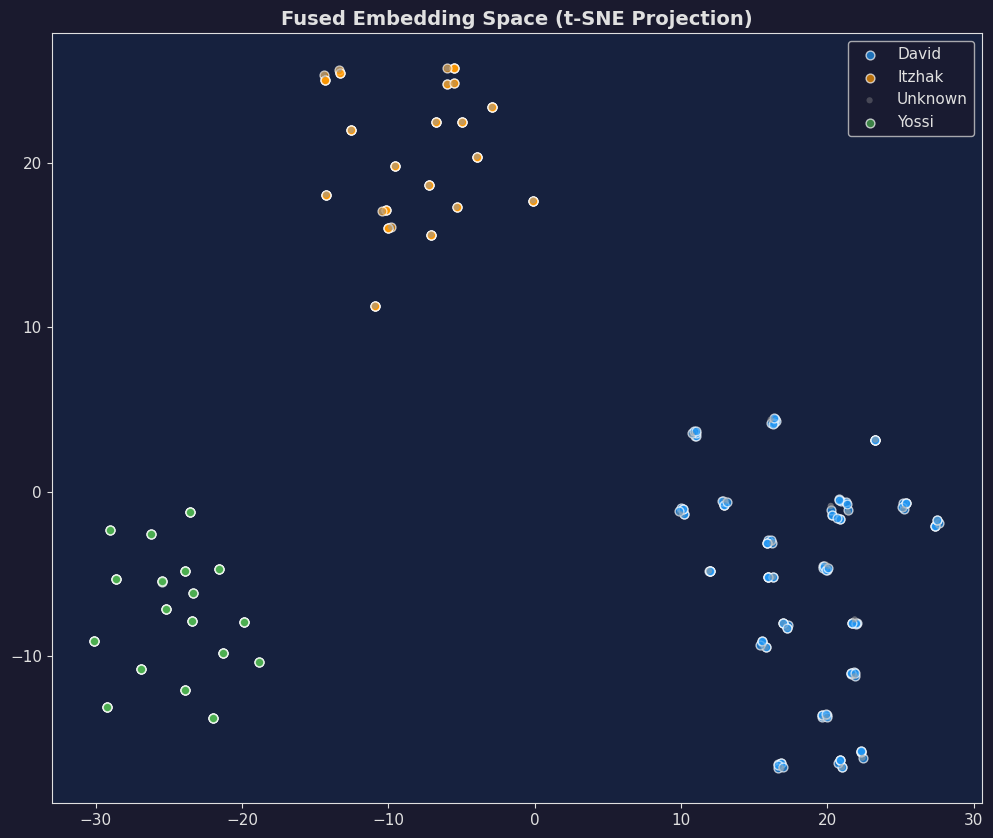


  [2/6] Generating training curves...


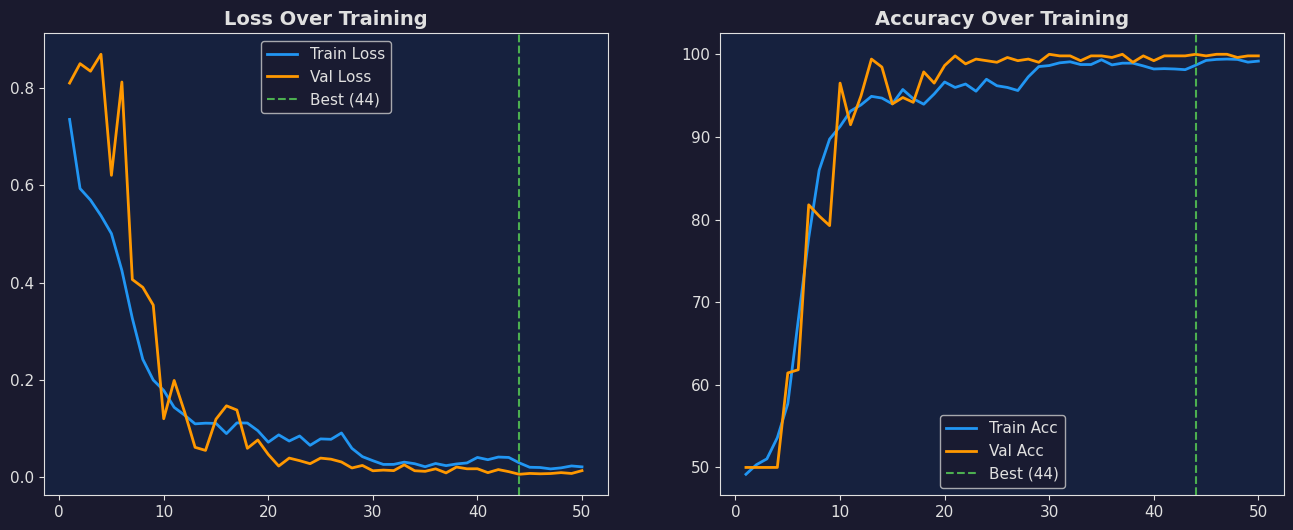


  [3/6] Generating confusion matrix...


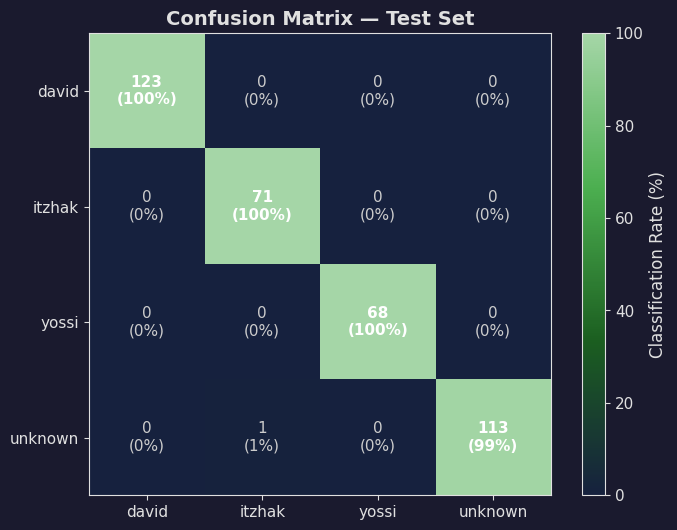


  [4/6] Generating similarity distributions...


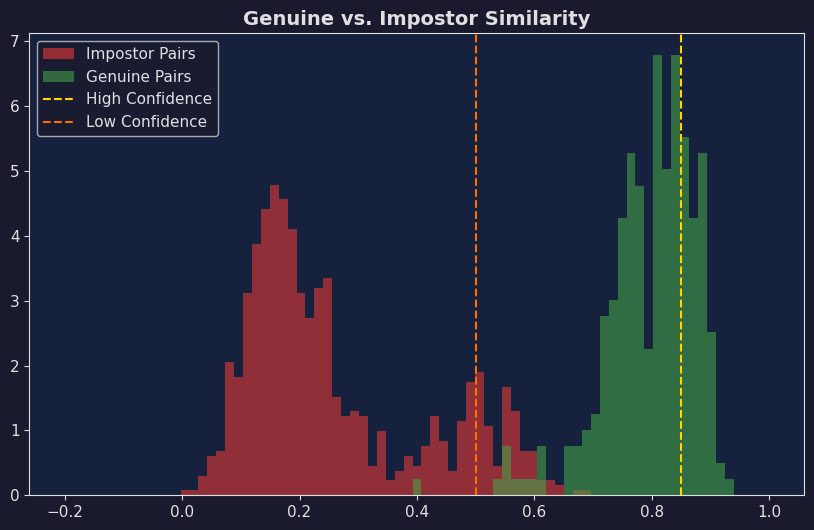


  [5/6] Generating per-class performance bars...


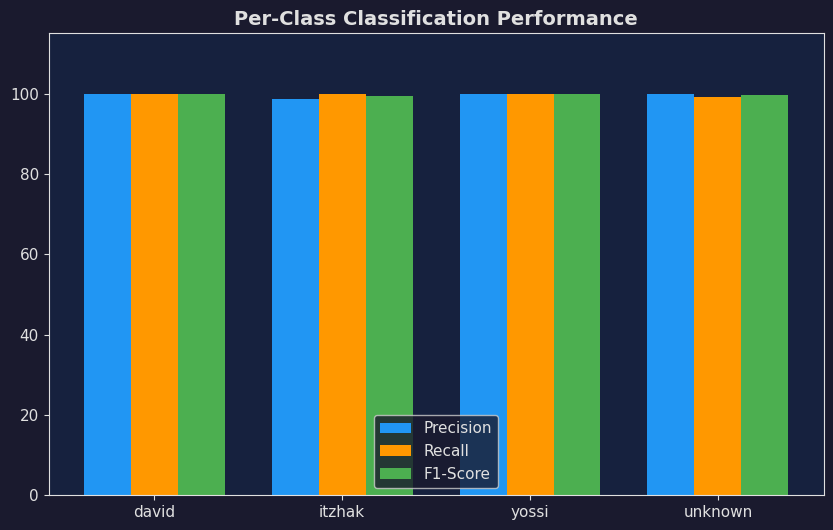


  [6/6] Generating system architecture diagram...


/tmp/ipykernel_30412/2189991464.py:25: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
/tmp/ipykernel_30412/2189991464.py:25: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
/tmp/ipykernel_30412/2189991464.py:25: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
/tmp/ipykernel_30412/2189991464.py:25: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fi

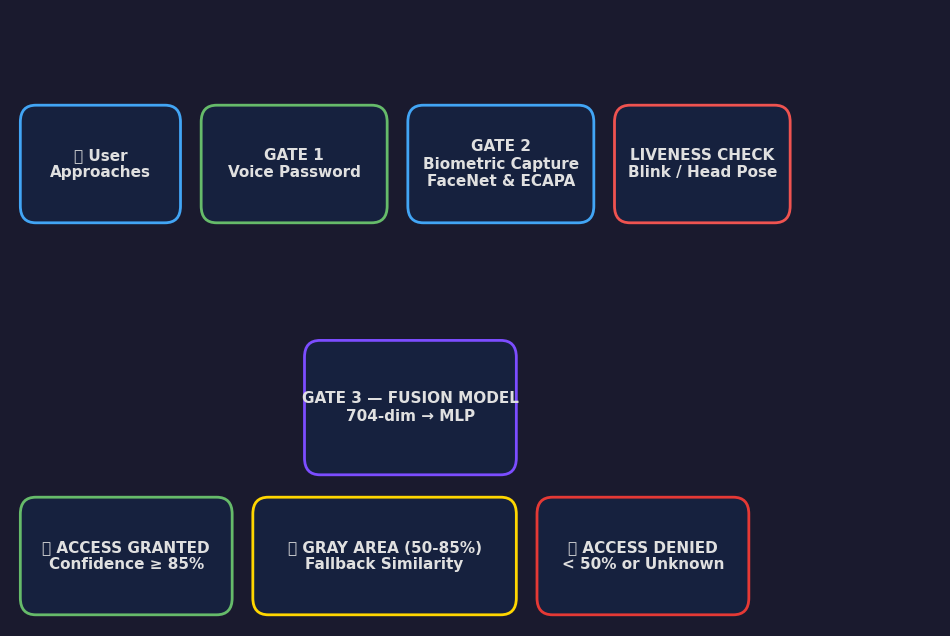


  Creating combined dashboard...
    ✓ Dashboard saved to: /content/drive/MyDrive/data/evaluation/figures/dashboard.png


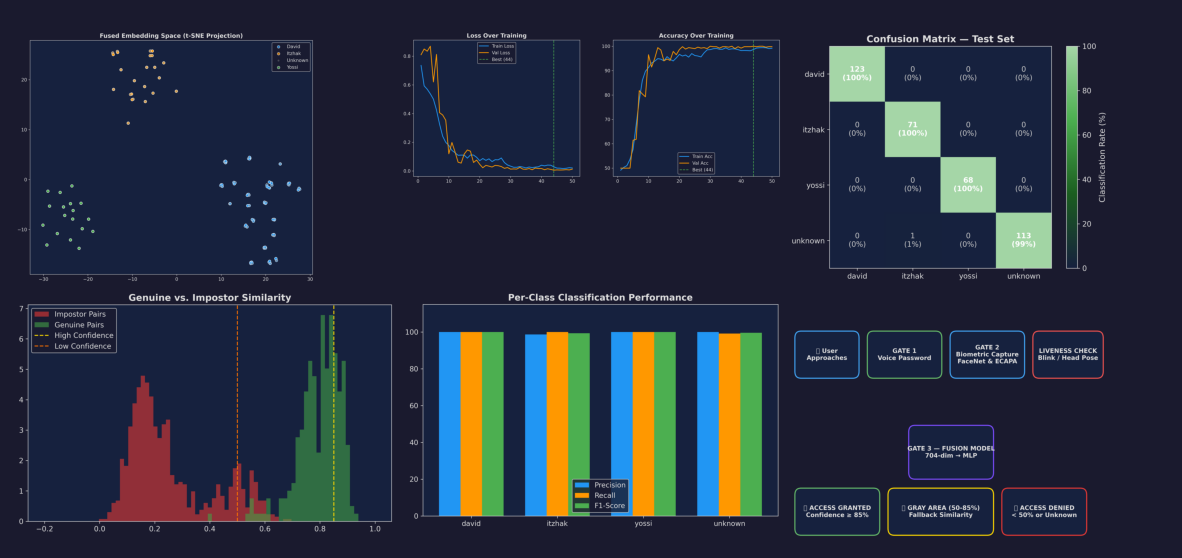


  All visualizations complete and saved to Drive!


In [ ]:
# ============================================================
#  13. Architecture Plot & Execution
# ============================================================

def plot_system_architecture(save_path):
    print("\n  [6/6] Generating system architecture diagram...")
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 18); ax.set_ylim(0, 11); ax.axis("off")

    def draw_box(x, y, w, h, text, color="#16213e", border="#4CAF50"):
        ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3", facecolor=color, edgecolor=border, lw=2))
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", color="#e0e0e0", fontweight="bold")

    draw_box(0.5, 7.5, 2.5, 1.5, "👤 User\nApproaches", border="#42A5F5")
    draw_box(4.0, 7.5, 3.0, 1.5, "GATE 1\nVoice Password", border="#66BB6A")
    draw_box(8.0, 7.5, 3.0, 1.5, "GATE 2\nBiometric Capture\nFaceNet & ECAPA", border="#42A5F5")
    draw_box(12.0, 7.5, 2.8, 1.5, "LIVENESS CHECK\nBlink / Head Pose", border="#EF5350")
    draw_box(6.0, 3.0, 3.5, 1.8, "GATE 3 — FUSION MODEL\n704-dim → MLP", border="#7C4DFF")

    # Decisions
    draw_box(0.5, 0.5, 3.5, 1.5, "🟢 ACCESS GRANTED\nConfidence ≥ 85%", border="#66BB6A")
    draw_box(5.0, 0.5, 4.5, 1.5, "🟡 GRAY AREA (50-85%)\nFallback Similarity", border="#FFD600")
    draw_box(10.5, 0.5, 3.5, 1.5, "🔴 ACCESS DENIED\n< 50% or Unknown", border="#E53935")

    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

def create_dashboard(figure_paths, save_path):
    print("\n  Creating combined dashboard...")
    images = [Image.open(p) for p in figure_paths if os.path.exists(p)]
    if len(images) < 2: return

    cols, rows = 3, 2
    cell_w, cell_h = 1800, 1200
    resized = [img.resize((int(img.width * min(cell_w/img.width, cell_h/img.height)),
                           int(img.height * min(cell_w/img.width, cell_h/img.height))), Image.LANCZOS) for img in images]

    padding, title_h = 20, 80
    dash_w = cols * max(i.width for i in resized) + (cols + 1) * padding
    dash_h = rows * max(i.height for i in resized) + (rows + 1) * padding + title_h

    dashboard = Image.new("RGB", (dash_w, dash_h), color=(26, 26, 46))
    for idx, img in enumerate(resized):
        x = padding + (idx % cols) * (max(i.width for i in resized) + padding)
        y = title_h + padding + (idx // cols) * (max(i.height for i in resized) + padding)
        dashboard.paste(img, (x, y))

    dashboard.save(save_path, quality=95)
    print(f"    ✓ Dashboard saved to: {save_path}")
    # Show scaled down version in Colab
    plt.figure(figsize=(15, 10)); plt.axis('off'); plt.imshow(dashboard); plt.show()

def run_visualizations():
    print("=" * 60)
    print("  PHASE 5: GENERATING VISUALIZATIONS")
    print("=" * 60)

    face_data, voice_data, splits_data, history, profiles, model = load_all_data_for_viz()
    fused_vectors, labels, label_names = build_fused_test_data(splits_data)

    paths = [os.path.join(FIGURES_DIR, f"{i}.png") for i in ["1_tsne", "2_curves", "3_cm", "4_sim", "5_perf", "6_arch"]]

    plot_tsne_clusters(fused_vectors, label_names, profiles, paths[0])
    plot_training_curves(history, paths[1])
    plot_confusion_matrix_viz(fused_vectors, labels, model, paths[2])
    plot_similarity_distributions(fused_vectors, label_names, profiles, paths[3])
    plot_per_class_performance(fused_vectors, labels, model, paths[4])
    plot_system_architecture(paths[5])

    create_dashboard(paths, os.path.join(FIGURES_DIR, "dashboard.png"))
    print("\n  All visualizations complete and saved to Drive!")

# ▶ Run the Suite
run_visualizations()

In [ ]:
# ============================================================
#  14. System Inference — Setup & Model Loading
# ============================================================
# This cell loads all AI models needed for inference.
# It reuses variables already defined in earlier cells:
#   - FusionModel class                           (cell 52)
#   - ALL_CLASSES, NUM_CLASSES, IDX_TO_CLASS       (cell 50)
#   - FUSED_EMBEDDING_DIM                          (cell 50)
#   - FACE_PROCESSED_DIR, VOICE_PROCESSED_DIR      (cells 10/11)
#   - TARGET_SAMPLE_RATE                            (cell 11)

import glob
import warnings
import tempfile
from datetime import datetime
from difflib import SequenceMatcher
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
#  Path Safety — .pt files live on Google Drive, NOT in the
#  cloned GitHub repo (.gitignore excludes them).
#  If earlier cells (47/50) weren't run or defined repo paths,
#  we fall back to the known Drive locations.
# ============================================================
_DRIVE_MODELS_DIR = "/content/drive/MyDrive/data/models"

# --- Fusion model ---
if not os.path.exists(FUSION_MODEL_PATH):
    _drive_fusion = os.path.join(_DRIVE_MODELS_DIR, "fusion_model.pt")
    if os.path.exists(_drive_fusion):
        FUSION_MODEL_PATH = _drive_fusion
        print(f"[PATH FIX] fusion_model.pt found on Drive: {FUSION_MODEL_PATH}")
    else:
        raise FileNotFoundError(
            f"fusion_model.pt not found at:\n"
            f"  • {FUSION_MODEL_PATH}\n"
            f"  • {_drive_fusion}\n"
            f"Run training/train_model.py first, or check your Drive path."
        )

# --- User profiles ---
if not os.path.exists(USER_PROFILES_PATH):
    _drive_profiles = os.path.join(_DRIVE_MODELS_DIR, "user_profiles.pt")
    if os.path.exists(_drive_profiles):
        USER_PROFILES_PATH = _drive_profiles
        print(f"[PATH FIX] user_profiles.pt found on Drive: {USER_PROFILES_PATH}")
    else:
        raise FileNotFoundError(
            f"user_profiles.pt not found at:\n"
            f"  • {USER_PROFILES_PATH}\n"
            f"  • {_drive_profiles}\n"
            f"Run data_preparation/enroll_users.py first, or check your Drive path."
        )

print(f"[PATHS] Fusion model:  {FUSION_MODEL_PATH}  ({'✓ exists' if os.path.exists(FUSION_MODEL_PATH) else '✗ MISSING'})")
print(f"[PATHS] User profiles: {USER_PROFILES_PATH}  ({'✓ exists' if os.path.exists(USER_PROFILES_PATH) else '✗ MISSING'})")

# --- Inference Config ---
VOICE_PASSWORD         = "my voice is my password"
PASSWORD_FUZZY_THRESH  = 0.75
PASSWORD_KEYWORDS      = ["voice", "password"]
CONFIDENCE_HIGH        = 0.85
CONFIDENCE_LOW         = 0.50
FACE_SIM_THRESHOLD     = 0.4
VOICE_SIM_THRESHOLD    = 0.4

# --- Dataset directories to search (in priority order) ---
FACE_SEARCH_DIRS = [FACE_PROCESSED_DIR, FACE_AUGMENTED_DIR, FACE_RAW_DIR]
VOICE_SEARCH_DIRS = [VOICE_PROCESSED_DIR, VOICE_AUGMENTED_DIR, VOICE_RAW_DIR]
FACE_EXTENSIONS  = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
VOICE_EXTENSIONS = ("*.wav", "*.flac", "*.mp3")

# ============================================================
#  Model Manager
# ============================================================
class SystemModels:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fusion_model  = None
        self.user_profiles = None
        self.mtcnn   = None
        self.facenet = None
        self.ecapa   = None

    def load_all(self):
        print("\n  Loading all AI models...")
        import time
        t0 = time.time()

        # 1. User Profiles
        print(f"    → User profiles ......... ", end="", flush=True)
        self.user_profiles = torch.load(
            USER_PROFILES_PATH, map_location=self.device, weights_only=False
        )
        users = [k for k in self.user_profiles.keys() if k != "unknown"]
        print(f"OK ({len(users)} enrolled: {', '.join(users)})")

        # 2. Fusion Model (uses FusionModel class from cell 52)
        print(f"    → Fusion Model .......... ", end="", flush=True)
        checkpoint = torch.load(
            FUSION_MODEL_PATH, map_location=self.device, weights_only=False
        )
        self.fusion_model = FusionModel().to(self.device)
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            self.fusion_model.load_state_dict(checkpoint["model_state_dict"])
        elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            self.fusion_model.load_state_dict(checkpoint["state_dict"])
        else:
            self.fusion_model.load_state_dict(checkpoint)
        self.fusion_model.eval()
        print("OK")

        # 3. Face Models (MTCNN + FaceNet)
        print(f"    → MTCNN + FaceNet ....... ", end="", flush=True)
        from facenet_pytorch import MTCNN, InceptionResnetV1
        self.mtcnn = MTCNN(
            image_size=160, margin=40, min_face_size=40,
            thresholds=[0.6, 0.7, 0.90],
            keep_all=False, select_largest=True, device=self.device
        )
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(self.device)
        print("OK")

        # 4. Voice Model (ECAPA-TDNN)
        print(f"    → ECAPA-TDNN ............ ", end="", flush=True)
        from speechbrain.inference.speaker import EncoderClassifier
        try:
            from speechbrain.utils.fetching import LocalStrategy
            self.ecapa = EncoderClassifier.from_hparams(
                source="speechbrain/spkrec-ecapa-voxceleb",
                savedir="models/voice/ecapa_tdnn",
                local_strategy=LocalStrategy.COPY,
                run_opts={"device": str(self.device)}
            )
        except ImportError:
            self.ecapa = EncoderClassifier.from_hparams(
                source="speechbrain/spkrec-ecapa-voxceleb",
                savedir="models/voice/ecapa_tdnn",
                run_opts={"device": str(self.device)}
            )
        print("OK")

        elapsed = time.time() - t0
        print(f"\n  ✓ All models loaded in {elapsed:.1f}s on {self.device}\n")


# --- Load everything ---
system_models = SystemModels()
system_models.load_all()


[PATHS] Fusion model:  /content/drive/MyDrive/data/models/fusion_model.pt  (✓ exists)
[PATHS] User profiles: /content/drive/MyDrive/data/models/user_profiles.pt  (✓ exists)

  Loading all AI models...
    → User profiles ......... OK (3 enrolled: david, itzhak, yossi)
    → Fusion Model .......... OK
    → MTCNN + FaceNet ....... OK
    → ECAPA-TDNN ............ 

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using file found at '/content/models/voice/ecapa_tdnn/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
DEBUG:speechbrain.utils.parameter_transfer:Collecting files (or symlinks) for pretraining in models/voice/ecapa_tdnn.
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using file found at '/content/models/voice/ecapa_tdnn/embedding_model.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["embedding_model"] = /content/models/voice/ecapa_tdnn/embedding_model.ckpt
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using file found at '/content/models/voice/ecapa_tdnn/mean_var_norm_emb.ckpt'
DEBUG:speechbrain.utils.parameter_transfer:Set local path in self.paths["mean_var_norm_emb"] = /content/models/voice/ecapa_tdnn/mean_var_norm_emb.ckpt
INFO:speechbrain.utils.fetching:Fetch classifier.ck

OK

  ✓ All models loaded in 0.9s on cuda



---
## 10. Live Authentication Pipeline (Demo)
Since we can't run a live camera/microphone in Colab, this demo simulates the full authentication flow by picking random face images and voice clips from the dataset — testing both legitimate users and impostor scenarios.

**The Decision Engine:**
The system simulates a secure, real-world authentication flow structured around 3 security gates:
* **Gate 1 - Voice Password:** A Speech-to-Text (STT) engine checks for liveness and specific keywords using a Fuzzy Matching algorithm against a target phrase.
* **Gate 2 - Biometric Scan:** Real-time extraction of 512-dim face and 192-dim voice embeddings.
* **Gate 3 - Fusion Decision:** The extracted data is fed into the MLP model. The final decision is tiered:
  - High Confidence (≥85%) → Absolute Access Granted.
  - Impostor Classification (Unknown) or Low Confidence (<50%) → Access Denied.
  - Gray Area (50%-85%) → Triggers a Fallback mechanism, issuing a decision based on direct Cosine Similarity calculation against the user's reference profile.

In [ ]:
# ============================================================
#  15. Authentication Pipeline Functions
# ============================================================

# ── Dataset Discovery ─────────────────────────────────────────

def discover_dataset():
    """
    Scan dataset directories and return available files per user.

    Returns:
        dict  {user: {"face": [paths], "voice": [paths]}}
        Only users with BOTH face and voice data are included.
    """
    dataset = {}
    print("\n  📂 Scanning dataset directories...")

    for user in AUTHORIZED_USERS:
        face_files  = []
        voice_files = []

        for base in FACE_SEARCH_DIRS:
            user_dir = os.path.join(base, user)
            if os.path.isdir(user_dir):
                for ext in FACE_EXTENSIONS:
                    face_files.extend(glob.glob(os.path.join(user_dir, ext)))
                if face_files:
                    break  # use highest-priority dir that has files

        for base in VOICE_SEARCH_DIRS:
            user_dir = os.path.join(base, user)
            if os.path.isdir(user_dir):
                for ext in VOICE_EXTENSIONS:
                    voice_files.extend(glob.glob(os.path.join(user_dir, ext)))
                # Also search category subfolders (password/short/long)
                for sub in os.listdir(user_dir):
                    sub_path = os.path.join(user_dir, sub)
                    if os.path.isdir(sub_path):
                        for ext in VOICE_EXTENSIONS:
                            voice_files.extend(glob.glob(os.path.join(sub_path, ext)))
                if voice_files:
                    break

        face_files  = sorted(set(face_files))
        voice_files = sorted(set(voice_files))

        if face_files and voice_files:
            dataset[user] = {"face": face_files, "voice": voice_files}
            print(f"    ✓ {user:<10} — {len(face_files):>4} face images, "
                  f"{len(voice_files):>4} voice clips")
        else:
            missing = []
            if not face_files:  missing.append("face")
            if not voice_files: missing.append("voice")
            print(f"    ✗ {user:<10} — MISSING: {', '.join(missing)}")

    if not dataset:
        print("\n  ⚠ NO USABLE DATA FOUND!")
        print("    Expected structure:")
        print(f"      {FACE_PROCESSED_DIR}/<user>/*.jpg")
        print(f"      {VOICE_PROCESSED_DIR}/<user>/*.wav")
    return dataset

dataset = discover_dataset()


# ── Embedding Extraction ──────────────────────────────────────

def extract_face_embedding(image_path, models):
    """
    Load a face image → MTCNN detect/align → FaceNet embed → 512-dim.
    Falls back to direct resize if MTCNN can't re-detect
    (common with already-processed 160×160 crops).
    """
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"    ✗ Cannot open image: {e}")
        return None

    face_tensor = models.mtcnn(img)

    if face_tensor is None:
        # Processed images are already 160×160 aligned crops — MTCNN
        # sometimes fails to re-detect in such tight crops.  Resize
        # and normalise manually (same transform MTCNN would output).
        try:
            xfm = transforms.Compose([
                transforms.Resize((160, 160)),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            ])
            face_tensor = xfm(img)
        except Exception as e2:
            print(f"    ✗ Fallback resize failed: {e2}")
            return None

    with torch.no_grad():
        emb = models.facenet(face_tensor.unsqueeze(0).to(models.device)).squeeze(0)
    return emb


def extract_voice_embedding(audio_path, models):
    """
    Load an audio file → resample to 16 kHz mono → ECAPA-TDNN → 192-dim.
    """
    try:
        waveform, sr = torchaudio.load(audio_path)
    except Exception as e:
        print(f"    ✗ Cannot load audio: {e}")
        return None

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != TARGET_SAMPLE_RATE:
        waveform = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)(waveform)

    with torch.no_grad():
        emb = models.ecapa.encode_batch(waveform.to(models.device))
        return emb.squeeze()


# ── Password Verification ─────────────────────────────────────

def verify_password_from_file(audio_path):
    """
    Transcribe an audio file via Google STT, then fuzzy-match
    against the stored password phrase.

    Returns (passed:bool, transcript:str, score:float)
    """
    try:
        import speech_recognition as _sr
    except ImportError:
        return False, "SpeechRecognition not installed", 0.0

    recognizer = _sr.Recognizer()
    try:
        with _sr.AudioFile(audio_path) as source:
            recognizer.adjust_for_ambient_noise(source, duration=0.3)
            audio = recognizer.record(source)
        transcript = recognizer.recognize_google(audio, language="en-US")
        transcript = transcript.strip().lower()
    except _sr.UnknownValueError:
        return False, "(could not understand audio)", 0.0
    except _sr.RequestError as e:
        return False, f"(STT API error: {e})", 0.0
    except Exception as e:
        return False, f"(error: {e})", 0.0

    similarity = SequenceMatcher(None, transcript, VOICE_PASSWORD).ratio()

    # Layer 1: full-phrase fuzzy match
    if similarity >= PASSWORD_FUZZY_THRESH:
        return True, transcript, similarity

    # Layer 2: keyword backup
    kw_found = sum(1 for kw in PASSWORD_KEYWORDS if kw in transcript)
    if kw_found >= len(PASSWORD_KEYWORDS):
        return True, transcript, max(similarity, 0.75)

    return False, transcript, similarity


# ── Fusion Model Decision Engine ──────────────────────────────

def make_decision(models, face_emb, voice_emb):
    """
    3-tier confidence logic:
      ≥ 85 %  → immediate ACCESS GRANTED
      50–85 % → gray area → cosine similarity fallback
      < 50 %  → ACCESS DENIED
    """
    fused = torch.cat([
        face_emb.to(models.device),
        voice_emb.to(models.device),
    ], dim=0).unsqueeze(0)

    with torch.no_grad():
        probs = torch.softmax(models.fusion_model(fused), dim=1).squeeze(0)

    conf, pred_idx = torch.max(probs, dim=0)
    user = ALL_CLASSES[pred_idx.item()]
    conf = conf.item()

    all_probs = {ALL_CLASSES[i]: probs[i].item() for i in range(NUM_CLASSES)}

    # Tier 1: HIGH confidence
    if user != "unknown" and conf >= CONFIDENCE_HIGH:
        return True, user, conf, "High Confidence", all_probs

    # Tier 3: LOW confidence or Unknown
    if conf < CONFIDENCE_LOW or user == "unknown":
        reason = "Unknown Class" if user == "unknown" else "Low Confidence"
        return False, user, conf, reason, all_probs

    # Tier 2: GRAY AREA → cosine fallback
    prof = models.user_profiles.get(user, {})
    ref_face  = prof.get("face_mean")
    ref_voice = prof.get("voice_mean")

    if ref_face is None or ref_voice is None:
        return False, user, conf, "Gray Area — Missing Profile", all_probs

    face_sim  = F.cosine_similarity(
        face_emb.unsqueeze(0).to(models.device),
        ref_face.unsqueeze(0).to(models.device)
    ).item()
    voice_sim = F.cosine_similarity(
        voice_emb.unsqueeze(0).to(models.device),
        ref_voice.unsqueeze(0).to(models.device)
    ).item()

    if face_sim >= FACE_SIM_THRESHOLD and voice_sim >= VOICE_SIM_THRESHOLD:
        return (True, user, conf,
                f"Gray Area Fallback (face={face_sim:.2f}, voice={voice_sim:.2f})",
                all_probs)

    return (False, user, conf,
            f"Fallback Failed (face={face_sim:.2f}, voice={voice_sim:.2f})",
            all_probs)



  📂 Scanning dataset directories...
    ✓ david      —   51 face images,   33 voice clips
    ✓ itzhak     —   29 face images,   30 voice clips
    ✓ yossi      —   28 face images,   30 voice clips


  DEMO OPTIONS  (copy one line, paste below, and run)
  run_authentication_test(mode="legitimate")
  run_authentication_test(mode="impostor")
  run_authentication_test(mode="custom", face_user="david", voice_user="yossi")
  run_batch_test(num_legitimate=3, num_impostor=3)

╔══════════════════════════════════════════════════════════╗
║  SECURE GATEWAY — Colab Demo Authentication               ║
╚══════════════════════════════════════════════════════════╝

  Mode: LEGITIMATE  —  DAVID's face + voice
  Expected: ACCESS GRANTED ✓

  📂 Face:  …/data/face/processed/david/45.png
  📂 Voice: …/data/voice/processed/david/longline4.wav

  🔐 AUTHENTICATION ATTEMPT  —  2026-03-18 20:08:38

  ────── GATE 1: VOICE PASSWORD ──────
  Password phrase: "my voice is my password"
    Heard: "in the year 1814 napoleon 44 france and defended it from invasion from the 6th coalition amazon"  (similarity: 17%)
  🔴 PASSWORD REJECTED — the voice clip did not contain the password.
     This is a dataset demo recor

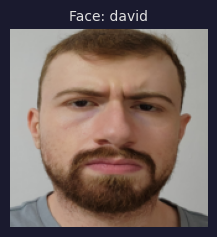


    🔊 Voice embedding...
    ✓ Voice embedded (192-dim)

  ────── LIVENESS CHECK ──────
  ⏭ Skipped (static images — no blink/pose data)

  ────── GATE 3: FUSION MODEL ──────

    🧠 Prediction: DAVID  (100.0%)
       david      100.0%  █████████████████████████████ ◄
       unknown      0.0%  
       yossi        0.0%  
       itzhak       0.0%  

  ╔══════════════════════════════════════════════════════╗
  ║              🟢 ACCESS GRANTED 🟢                   ║
  ╠══════════════════════════════════════════════════════╣
  ║  User:       DAVID                                    ║
  ║  Confidence: 100.0%                                   ║
  ║  Method:     High Confidence                          ║
  ╚══════════════════════════════════════════════════════╝

  📋 Expected: GRANTED  |  Actual: GRANTED  |  ✅ CORRECT


{'access_granted': True,
 'predicted_user': 'david',
 'confidence': 0.9996042847633362,
 'decision_path': 'High Confidence',
 'face_user': 'david',
 'voice_user': 'david'}

In [ ]:
# ============================================================
#  16. Run System — Random-Sample Demo from Dataset
# ============================================================
# Re-run this cell as many times as you like — it picks new
# random samples each time.
#
# Modes:
#   "legitimate" — same person's face + voice  → should GRANT
#   "impostor"   — different persons            → should DENY
#   "custom"     — you choose face_user & voice_user
# ============================================================

def run_authentication_test(mode="legitimate",
                            face_user=None,
                            voice_user=None,
                            show_image=True):
    """
    Run one full authentication attempt using random dataset samples.

    Parameters
    ----------
    mode : str
        "legitimate" | "impostor" | "custom"
    face_user, voice_user : str or None
        Override which user's data to use (required for "custom").
    show_image : bool
        True  → display the chosen face image inline
    """
    if not dataset:
        print("  ✗ No dataset available — see dataset discovery output above.")
        return None

    available = list(dataset.keys())

    # ── Select face / voice user based on mode ────────────────
    if mode == "legitimate":
        user = face_user if (face_user and face_user in dataset) else random.choice(available)
        face_user = voice_user = user
    elif mode == "impostor":
        if len(available) < 2:
            print("  ✗ Need ≥ 2 users for impostor mode."); return None
        if not (face_user and voice_user and face_user in dataset and voice_user in dataset
                and face_user != voice_user):
            pair = random.sample(available, 2)
            face_user, voice_user = pair[0], pair[1]
    elif mode == "custom":
        if not face_user or not voice_user:
            print("  ✗ Custom mode needs face_user and voice_user."); return None
        for u in (face_user, voice_user):
            if u not in dataset:
                print(f"  ✗ '{u}' not in dataset. Available: {available}"); return None
    else:
        print(f"  ✗ Unknown mode '{mode}'."); return None

    # ── Pick random files ─────────────────────────────────────
    face_path  = random.choice(dataset[face_user]["face"])
    voice_path = random.choice(dataset[voice_user]["voice"])

    same = face_user == voice_user
    tag  = f"{face_user.upper()}'s face + voice" if same \
           else f"{face_user.upper()}'s face  +  {voice_user.upper()}'s voice"

    print("\n" + "╔" + "═" * 58 + "╗")
    print("║  SECURE GATEWAY — Colab Demo Authentication               ║")
    print("╚" + "═" * 58 + "╝")
    print(f"\n  Mode: {mode.upper()}  —  {tag}")
    print(f"  Expected: {'ACCESS GRANTED ✓' if same else 'ACCESS DENIED ✗'}")
    print(f"\n  📂 Face:  …/{os.path.relpath(face_path, '/content/drive/MyDrive')}")
    print(f"  📂 Voice: …/{os.path.relpath(voice_path, '/content/drive/MyDrive')}")

    print("\n" + "=" * 60)
    print(f"  🔐 AUTHENTICATION ATTEMPT  —  {datetime.now():%Y-%m-%d %H:%M:%S}")
    print("=" * 60)

    # ── GATE 1: Voice Password ────────────────────────────────
    print(f'\n  ────── GATE 1: VOICE PASSWORD ──────')
    print(f'  Password phrase: "{VOICE_PASSWORD}"')

    # Always attempt real STT on the voice clip so the lecturer
    # sees the full pipeline in action.
    # If the voice file isn't WAV, convert to a temp WAV first.
    if voice_path.lower().endswith(".wav"):
        pw_passed, pw_transcript, pw_score = verify_password_from_file(voice_path)
    else:
        wf, _sr = torchaudio.load(voice_path)
        if wf.shape[0] > 1: wf = wf.mean(dim=0, keepdim=True)
        if _sr != TARGET_SAMPLE_RATE:
            wf = torchaudio.transforms.Resample(_sr, TARGET_SAMPLE_RATE)(wf)
        tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
        torchaudio.save(tmp.name, wf, TARGET_SAMPLE_RATE)
        pw_passed, pw_transcript, pw_score = verify_password_from_file(tmp.name)
        os.remove(tmp.name)

    print(f'    Heard: "{pw_transcript}"  (similarity: {pw_score:.0%})')

    if pw_passed:
        print("  🟢 PASSWORD ACCEPTED — correct phrase detected!")
    else:
        print("  🔴 PASSWORD REJECTED — the voice clip did not contain the password.")
        print("     This is a dataset demo recording, not a live password attempt.")
        print("     In the live system this would deny access immediately.")
        print("     ➤ Continuing to biometric gates for demonstration purposes...")

    # ── GATE 2: Biometric Scan ────────────────────────────────
    print(f"\n  ────── GATE 2: BIOMETRIC SCAN ──────")

    print(f"\n    📸 Face embedding...")
    face_emb = extract_face_embedding(face_path, system_models)
    if face_emb is None:
        print("  🔴 NO FACE EMBEDDED — ACCESS DENIED")
        return {"access_granted": False, "decision_path": "face_failed"}
    print(f"    ✓ Face embedded ({face_emb.shape[0]}-dim)")

    if show_image:
        try:
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
            ax.imshow(Image.open(face_path).convert("RGB"))
            ax.set_title(f"Face: {face_user}", fontsize=10)
            ax.axis("off"); plt.tight_layout(); plt.show()
        except Exception:
            pass

    print(f"\n    🔊 Voice embedding...")
    voice_emb = extract_voice_embedding(voice_path, system_models)
    if voice_emb is None:
        print("  🔴 NO VOICE EMBEDDED — ACCESS DENIED")
        return {"access_granted": False, "decision_path": "voice_failed"}
    print(f"    ✓ Voice embedded ({voice_emb.shape[0]}-dim)")

    # ── LIVENESS (skipped for static dataset) ─────────────────
    print(f"\n  ────── LIVENESS CHECK ──────")
    print(f"  ⏭ Skipped (static images — no blink/pose data)")

    # ── GATE 3: Fusion Model Decision ─────────────────────────
    print(f"\n  ────── GATE 3: FUSION MODEL ──────")
    granted, user, conf, reason, all_probs = make_decision(
        system_models, face_emb, voice_emb
    )

    # Show probability breakdown
    print(f"\n    🧠 Prediction: {user.upper()}  ({conf:.1%})")
    for label, p in sorted(all_probs.items(), key=lambda x: -x[1]):
        bar = "█" * int(p * 30)
        tag = " ◄" if label == user else ""
        print(f"       {label:<10} {p:6.1%}  {bar}{tag}")

    # ── Final Result ──────────────────────────────────────────
    print("\n" + "=" * 60)
    if granted:
        print(f"  ╔══════════════════════════════════════════════════════╗")
        print(f"  ║              🟢 ACCESS GRANTED 🟢                   ║")
        print(f"  ╠══════════════════════════════════════════════════════╣")
        print(f"  ║  User:       {user.upper():<40} ║")
        print(f"  ║  Confidence: {conf:<40.1%} ║")
        print(f"  ║  Method:     {reason[:40]:<40} ║")
        print(f"  ╚══════════════════════════════════════════════════════╝")
    else:
        print(f"  ╔══════════════════════════════════════════════════════╗")
        print(f"  ║              🔴 ACCESS DENIED 🔴                    ║")
        print(f"  ╠══════════════════════════════════════════════════════╣")
        print(f"  ║  Reason:     {reason[:40]:<40} ║")
        print(f"  ╚══════════════════════════════════════════════════════╝")
    print("=" * 60)

    # ── Correctness check ─────────────────────────────────────
    expected = (face_user == voice_user)
    correct  = granted == expected
    print(f"\n  📋 Expected: {'GRANTED' if expected else 'DENIED'}  |  "
          f"Actual: {'GRANTED' if granted else 'DENIED'}  |  "
          f"{'✅ CORRECT' if correct else '❌ UNEXPECTED'}")

    return {
        "access_granted": granted, "predicted_user": user,
        "confidence": conf, "decision_path": reason,
        "face_user": face_user, "voice_user": voice_user,
    }


# ============================================================
#  Batch Test — Run many trials at once
# ============================================================

def run_batch_test(num_legitimate=3, num_impostor=3):
    """
    Run multiple legitimate + impostor trials and print a summary table.
    """
    if not dataset:
        print("  ✗ No dataset."); return

    available = list(dataset.keys())
    results = []

    print("\n╔" + "═" * 58 + "╗")
    print("║  BATCH TEST SUITE                                        ║")
    print("╚" + "═" * 58 + "╝")

    for i in range(num_legitimate):
        u = available[i % len(available)]
        print(f"\n{'─'*60}\n  LEGITIMATE {i+1}/{num_legitimate}: {u.upper()}")
        r = run_authentication_test("custom", u, u, show_image=False)
        if r: results.append({**r, "type": "legitimate"})

    for i in range(num_impostor):
        pair = random.sample(available, 2)
        print(f"\n{'─'*60}\n  IMPOSTOR {i+1}/{num_impostor}: {pair[0].upper()} face + {pair[1].upper()} voice")
        r = run_authentication_test("custom", pair[0], pair[1], show_image=False)
        if r: results.append({**r, "type": "impostor"})

    # ── Summary Table ─────────────────────────────────────────
    legit = [r for r in results if r["type"] == "legitimate"]
    imps  = [r for r in results if r["type"] == "impostor"]
    lc = sum(1 for r in legit if r["access_granted"])
    ic = sum(1 for r in imps  if not r["access_granted"])
    total = len(results)
    acc = (lc + ic) / total if total else 0

    print(f"\n\n{'='*70}")
    print(f"  BATCH RESULTS")
    print(f"{'='*70}")
    print(f"  Legitimate: {lc}/{len(legit)} correctly GRANTED")
    print(f"  Impostor:   {ic}/{len(imps)} correctly DENIED")
    print(f"  Accuracy:   {lc+ic}/{total} ({acc:.0%})")
    print(f"\n  {'Type':<12} {'Face':<10} {'Voice':<10} {'Result':<10} "
          f"{'Predicted':<10} {'Conf':<8} {'OK'}")
    print(f"  {'─'*66}")
    for r in results:
        g = "GRANTED" if r["access_granted"] else "DENIED"
        exp = r["type"] == "legitimate"
        ok  = "✅" if r["access_granted"] == exp else "❌"
        print(f"  {r['type']:<12} {r.get('face_user','?'):<10} "
              f"{r.get('voice_user','?'):<10} {g:<10} "
              f"{r.get('predicted_user','?'):<10} "
              f"{r.get('confidence',0):<8.1%} {ok}")
    print(f"  {'─'*66}\n")
    return results


# ============================================================
#  🚀 RUN THE DEMO 🚀
# ============================================================
# Change mode / users below, then re-run this cell!
#
# --- Single tests ---
# run_authentication_test(mode="legitimate")
# run_authentication_test(mode="impostor")
# run_authentication_test(mode="custom", face_user="david", voice_user="yossi")
# # (STT always runs now — no skip_password needed)
#
# --- Batch test ---
# run_batch_test(num_legitimate=3, num_impostor=3)

print("=" * 60)
print("  DEMO OPTIONS  (copy one line, paste below, and run)")
print("=" * 60)
print('  run_authentication_test(mode="legitimate")')
print('  run_authentication_test(mode="impostor")')
print('  run_authentication_test(mode="custom", face_user="david", voice_user="yossi")')
print('  run_batch_test(num_legitimate=3, num_impostor=3)')
print("=" * 60)

# --- Run a legitimate attempt by default ---
run_authentication_test(mode="legitimate")


  SECURE GATEWAY — AUTHENTICATION SHOWCASE
  Running 3 tests: legitimate → impostor → custom

╔══════════════════════════════════════════════════════════╗
║  SECURE GATEWAY — Colab Demo Authentication               ║
╚══════════════════════════════════════════════════════════╝

  Mode: LEGITIMATE  —  ITZHAK's face + voice
  Expected: ACCESS GRANTED ✓

  📂 Face:  …/data/face/processed/itzhak/IMG_1769.png
  📂 Voice: …/data/voice/processed/itzhak/A27.wav

  🔐 AUTHENTICATION ATTEMPT  —  2026-03-18 20:14:48

  ────── GATE 1: VOICE PASSWORD ──────
  Password phrase: "my voice is my password"
    Heard: "i'm very tired and i just want to go home"  (similarity: 25%)
  🔴 PASSWORD REJECTED — the voice clip did not contain the password.
     This is a dataset demo recording, not a live password attempt.
     In the live system this would deny access immediately.
     ➤ Continuing to biometric gates for demonstration purposes...

  ────── GATE 2: BIOMETRIC SCAN ──────

    📸 Face embedding...
    

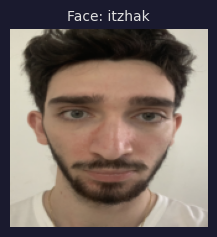


    🔊 Voice embedding...
    ✓ Voice embedded (192-dim)

  ────── LIVENESS CHECK ──────
  ⏭ Skipped (static images — no blink/pose data)

  ────── GATE 3: FUSION MODEL ──────

    🧠 Prediction: ITZHAK  (100.0%)
       itzhak     100.0%  █████████████████████████████ ◄
       unknown      0.0%  
       david        0.0%  
       yossi        0.0%  

  ╔══════════════════════════════════════════════════════╗
  ║              🟢 ACCESS GRANTED 🟢                   ║
  ╠══════════════════════════════════════════════════════╣
  ║  User:       ITZHAK                                   ║
  ║  Confidence: 100.0%                                   ║
  ║  Method:     High Confidence                          ║
  ╚══════════════════════════════════════════════════════╝

  📋 Expected: GRANTED  |  Actual: GRANTED  |  ✅ CORRECT

╔══════════════════════════════════════════════════════════╗
║  SECURE GATEWAY — Colab Demo Authentication               ║
╚═════════════════════════════════════════════════════

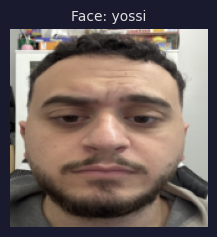


    🔊 Voice embedding...
    ✓ Voice embedded (192-dim)

  ────── LIVENESS CHECK ──────
  ⏭ Skipped (static images — no blink/pose data)

  ────── GATE 3: FUSION MODEL ──────

    🧠 Prediction: UNKNOWN  (99.9%)
       unknown     99.9%  █████████████████████████████ ◄
       yossi        0.1%  
       david        0.1%  
       itzhak       0.0%  

  ╔══════════════════════════════════════════════════════╗
  ║              🔴 ACCESS DENIED 🔴                    ║
  ╠══════════════════════════════════════════════════════╣
  ║  Reason:     Unknown Class                            ║
  ╚══════════════════════════════════════════════════════╝

  📋 Expected: DENIED  |  Actual: DENIED  |  ✅ CORRECT

╔══════════════════════════════════════════════════════════╗
║  SECURE GATEWAY — Colab Demo Authentication               ║
╚══════════════════════════════════════════════════════════╝

  Mode: CUSTOM  —  DAVID's face  +  YOSSI's voice
  Expected: ACCESS DENIED ✗

  📂 Face:  …/data/face/processed/da

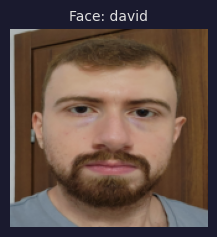


    🔊 Voice embedding...
    ✓ Voice embedded (192-dim)

  ────── LIVENESS CHECK ──────
  ⏭ Skipped (static images — no blink/pose data)

  ────── GATE 3: FUSION MODEL ──────

    🧠 Prediction: UNKNOWN  (98.0%)
       unknown     98.0%  █████████████████████████████ ◄
       yossi        2.0%  
       david        0.0%  
       itzhak       0.0%  

  ╔══════════════════════════════════════════════════════╗
  ║              🔴 ACCESS DENIED 🔴                    ║
  ╠══════════════════════════════════════════════════════╣
  ║  Reason:     Unknown Class                            ║
  ╚══════════════════════════════════════════════════════╝

  📋 Expected: DENIED  |  Actual: DENIED  |  ✅ CORRECT


In [ ]:
# ============================================================
#  🚀 SHOWCASE — One run of each authentication mode
# ============================================================
# This cell demonstrates the full authentication pipeline in
# three scenarios: legitimate access, impostor attempt, and
# a specific cross-user custom test.
# ============================================================

print("=" * 60)
print("  SECURE GATEWAY — AUTHENTICATION SHOWCASE")
print("=" * 60)
print("  Running 3 tests: legitimate → impostor → custom")

# ── Test 1: Legitimate — Itzhak's face + voice → should GRANT
_ = run_authentication_test(mode="legitimate", face_user="itzhak")

# ── Test 2: Impostor — Yossi's face + random other voice → should DENY
_ = run_authentication_test(mode="impostor", face_user="yossi")

# ── Test 3: Custom — David's face + Yossi's voice → should DENY
_ = run_authentication_test(mode="custom", face_user="david", voice_user="yossi")

---
## 11. Results & Conclusion

### Final Performance

| Metric | Value |
|---|---|
| **Test Accuracy** | 99.5% (376/378 samples) |
| David Accuracy | 100% |
| Itzhak Accuracy | 100% |
| Yossi Accuracy | 100% |
| Unknown Detection | 98% recall, 100% precision |

### Key Design Decisions That Worked

1. **Split before pairing** — Train/val/test splits are done on individual embeddings *before* creating face-voice pairs. This prevents data leakage where the same face or voice appears in both training and testing.

2. **BatchNorm in the fusion MLP** — Voice embeddings (192-dim) have ~800x larger variance than face embeddings (512-dim). Without BatchNorm, the model would ignore face features entirely.

3. **Unknown class via cross-person pairing** — Instead of collecting "unknown" data, we generate impostor pairs by mismatching face and voice from different users. This teaches the model to detect face-voice mismatches.

4. **3-Tier decision logic** — High confidence (≥85%) grants immediate access, low confidence (<50%) denies immediately, and the gray area (50-85%) falls back to cosine similarity against enrollment profiles. This balances security with user experience.

5. **Late Fusion** — Keeping face and voice as separate embeddings until the final classification layer allows each modality to contribute independently, rather than forcing early feature mixing.

### Limitations & Future Work

- **Small dataset** — Only 3 registered users with ~30 samples each. A production system would need hundreds of users.
- **Liveness detection** — Currently uses blink + head pose; could be strengthened with depth cameras or challenge-response.
- **Environment sensitivity** — Performance under extreme noise or lighting has not been tested extensively.